# **Clinical Trial Success Prediction: Strategic Benchmark & Validation Audit (v33.0)**

This notebook serves as the **Clinical Validation Sandbox**.


#### <REF:ENV_CONFIG>
> #### **1. Development Environment Configuration**

To ensure a seamless development workflow, we configure dynamic module reloading and precision-focused warning filters. This allows for iterative refinement of the `src` modules without requiring kernel restarts.


In [1]:
# <REF:ENV_CONFIG_CODE>
# --- AUTO-RELOAD MAGIC COMMANDS ---
%load_ext autoreload
%autoreload 2

import warnings
# 1. Initialize TQDM for Pandas (Enables progress_apply)
from tqdm.auto import tqdm
tqdm.pandas()

# 2. Silence Warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# <REF:/ENV_CONFIG_CODE>


#### <REF:PATH_RESOLUTION>
> #### **2. Project Path Resolution and Dynamic Imports**

*   **Dynamic Root Detection:** Implements a filesystem traversal algorithm to automatically locate the project root by searching for the `src` directory, ensuring portability across different environments (local vs. cloud).
*   **Environment Path Augmentation:** Appends the identified root directory to the system’s `PYTHONPATH`, enabling the usage of absolute imports (e.g., `import src.etl`) regardless of the notebook's location.
*   **Directory Standardization:** Defines and verifies global path constants (`DATA_PATH`, `MODELS_PATH`) to ensure consistent file I/O operations throughout the pipeline.

***

<REF:/PATH_RESOLUTION>


In [2]:
# <REF:PATH_RESOLUTION_CODE>
import sys
from pathlib import Path

# 1. Define the Project Root
# Start at the current directory and look for 'src' to identify the root
current_dir = Path.cwd()
project_root = current_dir

while not (project_root / 'src').exists():
    if project_root == project_root.parent:
        # Hit the filesystem root without finding the project
        raise FileNotFoundError("Could not find project root containing 'src'")
    project_root = project_root.parent

# 2. Add Project Root to System Path
# This allows 'import src...' to work from anywhere
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# 3. Define Key Paths
DATA_PATH = project_root / "data"
MODELS_PATH = project_root / "models"

# 4. Verification
print(f"Project Root: {project_root}")
print(f"Data Path:    {DATA_PATH}")
print(f"Models Path:  {MODELS_PATH}")

# <REF:/PATH_RESOLUTION_CODE>


Project Root: /home/delaunan/code/delaunan/clintrialpredict
Data Path:    /home/delaunan/code/delaunan/clintrialpredict/data
Models Path:  /home/delaunan/code/delaunan/clintrialpredict/models


#### <REF:LIB_INIT>
> #### **3. Library and Custom Module Initialization**

*   **Analytical Framework Setup:** Imports the foundational Python libraries for structured data manipulation (`pandas`, `numpy`) and statistical visualization (`matplotlib`, `seaborn`).
*   **Domain-Specific Module Import:**
    *   Initializes the `ClinicalTrialLoader`: The custom ETL engine responsible for ingesting raw AACT data, enforcing inclusion criteria, and executing domain-specific feature engineering.
    *   Initializes the `preprocessor`: The pipeline factory that constructs the `ColumnTransformer` for rigorous feature scaling, encoding, and dimensionality reduction.

***

<REF:/LIB_INIT>


In [3]:
# <REF:LIB_INIT_CODE>
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Custom Modules/Classes
from src.prep.data_loader_clinpred import ClinicalTrialLoader
from src.prep.pipeline import preprocessor


# <REF:/LIB_INIT_CODE>


#### <REF:DATA_PIPELINE>
> #### **4.A Automated Data Pipeline & Workflow Integrity**

The pipeline executes a multi-stage ETL process to generate the analytical cohort. It includes a **Binary Workflow Decision** based on the availability of BioBERT embeddings. If embeddings are detected, the system locks the dataset for training; otherwise, it sanitizes text for external vectorization.


In [4]:
# <REF:DATA_PIPELINE_CODE>
from dotenv import load_dotenv
load_dotenv()

REBUILD_DATA_CLINPRED = False
DATA_CLINPRED_PATH = DATA_PATH / "data_clinpred.csv"

def build_production_universe():
    loader = ClinicalTrialLoader(str(DATA_PATH))
    df_built = loader.load_base_data()
    df_built = loader.add_features(df_built)
    df_built.to_csv(DATA_CLINPRED_PATH, index=False)
    print(">>> Production Data Loaded & Saved. Final Shape: " + str(df_built.shape))
    return df_built

if REBUILD_DATA_CLINPRED or not DATA_CLINPRED_PATH.exists():
    if REBUILD_DATA_CLINPRED:
        print(">>> REBUILD_DATA_CLINPRED=True. Regenerating Production Universe from raw AACT files...")
    else:
        print(">>> data_clinpred.csv not found. Initializing full Production Ingestion...")
    df_full = build_production_universe()
else:
    df_full = pd.read_csv(DATA_CLINPRED_PATH, low_memory=False)
    print(">>> Loaded Production Universe from CSV | Shape: " + str(df_full.shape))

print(f"    Total Universe: {len(df_full):,} trials")
# <REF:/DATA_PIPELINE_CODE>


>>> Loaded Production Universe from CSV | Shape: (34066, 161)
    Total Universe: 34,066 trials


#### <REF:DATA_AUDIT>
> #### **4.B Forensic Data Audit: Integrity & Schema Verification**

Before modeling, we execute a forensic audit to ensure dataset completeness. This phase checks for row loss during CSV parsing, enforces critical numeric types, and verifies the density of the NLP feature store.


In [5]:
# <REF:DATA_AUDIT_CODE>
import pandas as pd
import numpy as np
import os
import sys

# --- CONFIGURATION ---
FILE_PATH = DATA_PATH / "data_clinpred.csv"

def audit_data_integrity():
    print("="*100)
    print(f"FORENSIC DATA AUDIT: {os.path.basename(FILE_PATH)}")
    print("="*100)

    if not FILE_PATH.exists():
        print(f"[CRITICAL] File not found at: {FILE_PATH}")
        return

    # 1. THE "SKIPPED LINE" CHECK (Raw vs Parsed)
    print(">>> Phase 1: Integrity Check (Did we lose rows?)")
    with open(FILE_PATH, 'rb') as f: raw_line_count = sum(1 for _ in f)
    df_full = pd.read_csv(FILE_PATH, low_memory=False)
    df_rows = len(df_full)
    expected_rows = raw_line_count - 1
    diff = expected_rows - df_rows

    print(f"    Raw File Lines:      {raw_line_count:,}")
    print(f"    DataFrame Rows:      {df_rows:,}")

    if diff == 0: print("    [PASS] Perfect Match. No lines skipped.")
    else: print(f"    [WARN] Discrepancy: {diff} lines skipped (Check for internal newlines).")

    # 2. CRITICAL COLUMN TYPE CHECK
    print("\n>>> Phase 2: Critical Type Enforcement")
    critical_checks = {
        'start_year': [np.integer, np.floating],
        'target':     [np.integer, np.floating],
        'nct_id':     [object, str]
    }
    for col, valid_types in critical_checks.items():
        if col not in df_full.columns:
            print(f"    [FAIL] Missing Column: {col}")
            continue
        actual_type = df_full[col].dtype
        is_valid = any(np.issubdtype(actual_type, t) for t in valid_types)
        status = "[PASS]" if is_valid else "[FAIL]"
        print(f"    {status} {col:<15} | Type: {actual_type}")

    # 3. EMBEDDING PRESENCE CHECK
    #emb: Embedding check updated to reflect disabled status
    print("\n>>> Phase 3: Feature Store Content (Embeddings DISABLED)")
    # emb_cols = [c for c in df_full.columns if c.startswith('crit_')]
    # if len(emb_cols) > 0:
    #     print(f"    [INFO] Embeddings Detected: {len(emb_cols)} dimensions found.")
    #     sample_sum = df_full[emb_cols[0]].sum()
    #     if sample_sum == 0: print("    [FAIL] Embeddings appear to be all zeros!")
    #     else: print("    [PASS] Embeddings contain non-zero data.")
    # else: print("    [INFO] No Embeddings found (Expected: Embeddings are currently disabled).")

    # 4. DETAILED MISSING VALUE REPORT
    print("\n>>> Phase 4: Detailed Column Scan")
    print("-" * 100)
    print(f"{'COLUMN NAME':<35} | {'DTYPE':<10} | {'MISSING':<8} | {'%':<6} | {'SAMPLE VALUE'}")
    print("-" * 100)
    for col in df_full.columns:
        if col.startswith(('crit_', 'sci_', 'endp_')) and col != 'crit_0': continue
        if col == 'crit_0':
            print(f"{'... [Embeddings Hidden] ...':<35} | {'float':<10} | {'0':<8} | {'0.0%':>4} | {'(Vectors)'}")
            continue
        dtype = str(df_full[col].dtype)
        n_miss = df_full[col].isna().sum()
        pct_miss = (n_miss / len(df_full)) * 100
        sample = df_full[col].dropna().iloc[0] if n_miss < len(df_full) else "ALL NAN"
        sample_str = str(sample)[:25]
        flag = " [!]" if pct_miss > 0 else ""
        print(f"{col:<35} | {dtype:<10} | {n_miss:<8} | {pct_miss:>4.1f}% | {sample_str:<25}{flag}")
    print("-" * 100)

if __name__ == "__main__":
    audit_data_integrity()

# <REF:/DATA_AUDIT_CODE>


FORENSIC DATA AUDIT: data_clinpred.csv
>>> Phase 1: Integrity Check (Did we lose rows?)
    Raw File Lines:      1,230,139
    DataFrame Rows:      34,066
    [WARN] Discrepancy: 1196072 lines skipped (Check for internal newlines).

>>> Phase 2: Critical Type Enforcement
    [PASS] start_year      | Type: float64
    [PASS] target          | Type: float64
    [PASS] nct_id          | Type: object

>>> Phase 3: Feature Store Content (Embeddings DISABLED)

>>> Phase 4: Detailed Column Scan
----------------------------------------------------------------------------------------------------
COLUMN NAME                         | DTYPE      | MISSING  | %      | SAMPLE VALUE
----------------------------------------------------------------------------------------------------
nct_id                              | object     | 0        |  0.0% | NCT02584816              
start_date                          | object     | 0        |  0.0% | 2015-11-30               
completion_date_type         

#### <REF:NLP_AUDIT>
> #### **5. Pre-Computation NLP Signal & Leakage Audit**

This audit scans text fields for 'Day Zero' violations (administrative keywords like 'updated' or NCT IDs) that could cause artificial performance inflation. It also validates the preservation of scientific nomenclature (e.g., RECIST, OS) to ensure the embedding model receives high-signal input.


In [6]:
# <REF:NLP_AUDIT_CODE>
#emb: Forensic NLP Audit disabled as embeddings are not currently used.
# import pandas as pd
# import re
#
# # Source for BioBERT processing (The 'Delta' export file)
# # Note: This file is deleted by append_new_embeddings() after successful merge.
# # If missing, we audit the main 'data_clinpred.csv' instead.
# file_delta = DATA_PATH / "data_clinpred_emb_transform.csv"
# file_main = DATA_PATH / "data_clinpred.csv"
#
# if file_delta.exists():
#     file_to_audit = file_delta
#     audit_mode = "DELTA (Pre-Merge)"
# elif file_main.exists():
#     file_to_audit = file_main
#     audit_mode = "PRODUCTION (Post-Merge)"
# else:
#     file_to_audit = None
#
# if file_to_audit is None:
#     print(f"[!] Audit Skip: No NLP source files found.")
# else:
#     # For large production files, we audit a sample or just the last 1000 rows
#     # to maintain speed while checking for recent leakage patterns.
#     if audit_mode == "PRODUCTION (Post-Merge)":
#         df_audit = pd.read_csv(file_to_audit, low_memory=False).tail(2000)
#     else:
#         df_audit = pd.read_csv(file_to_audit)
#
#     print("="*80); print(f"FORENSIC NLP AUDIT (v17.0 SHIELD) - {audit_mode}"); print("="*80)
#     print(f"Target File: {file_to_audit.name}")
#
#     # 1. INTEGRITY: Multi-Pillar Check
#     text_pillars = ["txt_scientific_essence", "txt_primary_endpoints", "txt_criteria"]
#     print(f"[1] Integrity: Rows Audited={len(df_audit)}")
#     for col in text_pillars:
#         if col in df_audit.columns:
#             missing = df_audit[col].isna().sum()
#             print(f"  - {col:<25} | Missing: {missing}")
#         else:
#             print(f"  - {col:<25} | [MISSING COLUMN]")
#
#     # 2. ZERO-LEAK VIOLATION: Searching for Sample Sizes (N=) in text
#     print("\n[2] Zero-Leak Violation (N= / Sample Size markers):")
#     leak_pattern = r"\b(?:N\s*=\s*\d+|enrollment\s*of\s*\d+|sample\s*size\s*\d+)\b"
#     total_leaks = 0
#     total_leaks = 0
#     for col in text_pillars:
#         if col in df_audit.columns:
#             leaks = df_audit[col].astype(str).str.contains(leak_pattern, case=False, regex=True).sum()
#             print(f"  - {col:<25}: {leaks} leaks detected")
#             total_leaks += leaks
#
#     # 3. ADMINISTRATIVE LEAKAGE: Searching for 'after-the-fact' markers
#     leakage_keywords = ["amendment", "protocol v", "version", "updated", "modified", "clinicaltrials.gov"]
#     print("[3] Administrative Markers (Lower is better):")
#     for word in leakage_keywords:
#         if "txt_criteria" in df_audit.columns:
#             count = df_audit["txt_criteria"].astype(str).str.contains(re.escape(word), case=False).sum()
#             print(f"  - '{word}': {count}")
#
#     # 4. SCIENTIFIC SIGNAL: Validating clinical nomenclature retention
#     print("[4] Scientific Signal Preservation (Clinical Rigor):")
#     protected = ["RECIST", "HbA1c", "ECOG", "NYHA", "mg/kg", "ORR", "OS"]
#     for term in protected:
#         if "txt_criteria" in df_audit.columns:
#             count = df_audit["txt_criteria"].astype(str).str.contains(re.escape(term), case=False).sum()
#             print(f"  - '{term}': {count}")
#
#     print("" + "="*80)
#     if total_leaks > 0:
#         print(f"AUDIT COMPLETE: [WARN] {total_leaks} Leakage points found in {audit_mode} sample.")
#     else:
#         print(f"AUDIT COMPLETE: [PASS] No major leakage violations detected in {audit_mode} sample.")
#     print("="*80)
# <REF:/NLP_AUDIT_CODE>


#### <REF:TEMP_SPLIT>
> #### **6. Temporal Partitioning: The Golden Split**

To simulate a forward-looking deployment, we partition data by time. The **Training Set (2009–2020)** establishes historical patterns, while the **Blind Test Set (2021–2022)** measures the model's ability to predict trials that haven't happened yet in the training distribution.


In [7]:
# <REF:TEMP_SPLIT_CODE>
TRAIN_START_YEAR = int(os.getenv('TRAIN_START_YEAR', 2009))
TRAIN_END_YEAR   = int(os.getenv('TRAIN_END_YEAR', 2021))
TEST_START_YEAR  = int(os.getenv('TEST_START_YEAR', 2022))
TEST_END_YEAR    = int(os.getenv('TEST_END_YEAR', 2023))

# 1. Filter for Historical Outcomes only & Promote NCT_ID as Identity Anchor
df_historical = df_full[df_full['target'].notna()].copy()
df_historical = df_historical.set_index('nct_id')

# 2. Identify Model-Ready Features & Anchors
#emb: Identifies numerical, categorical, and BioBERT embedding columns for model input.
cols_to_keep = [c for c in df_historical.columns if c.endswith('_ml') or
                # c.startswith(('crit_', 'sci_', 'endp_')) or
                c == 'therapeutic_area']

# 3. Apply Temporal Split
mask_train = df_historical['start_year'].between(TRAIN_START_YEAR, TRAIN_END_YEAR)
mask_test  = df_historical['start_year'].between(TEST_START_YEAR, TEST_END_YEAR)

# 4. Prepare Training (Sorted by Date)
df_train = df_historical.loc[mask_train].copy()
df_train['start_date'] = pd.to_datetime(df_train['start_date'], errors='coerce')
df_train = df_train.sort_values(by=['start_date'])
X_train, y_train = df_train[cols_to_keep], df_train["target"]

# 5. Prepare Testing
df_test = df_historical.loc[mask_test].copy()
df_test['start_date'] = pd.to_datetime(df_test['start_date'], errors='coerce')
df_test = df_test.sort_values(by=['start_date'])
X_test, y_test = df_test[cols_to_keep], df_test["target"]

# 6. Verification Audit
print(f'>>> Split Strategy Applied (Universal -> Historical):')
print(f'    Training: {TRAIN_START_YEAR}-{TRAIN_END_YEAR} | N={len(X_train):,}')
print(f'    Testing:  {TEST_START_YEAR}-{TEST_END_YEAR} | N={len(X_test):,}')
# <REF:/TEMP_SPLIT_CODE>


>>> Split Strategy Applied (Universal -> Historical):
    Training: 2009-2021 | N=23,091
    Testing:  2022-2023 | N=2,306


#### <REF:MODEL_TRAIN>
> #### **7. Model Configuration: XGBoost with Class Balancing**

We utilize an XGBoost classifier with strict regularization (shallow trees, high alpha/lambda) to prioritize broad, generalizable patterns over noise. To handle the natural class imbalance (trials succeed more often than they fail), we calculate `scale_pos_weight`, forcing the model to pay more attention to the minority failure class.


In [8]:
# <REF:MODEL_TRAIN_CODE>
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from src.prep.pipeline import preprocessor

print('\n=== STEP 7: TRAINING MODEL ===')

# Imbalance Handling: Ratio of Successes to Failures
n_pos = y_train.sum(); ratio = (len(y_train) - n_pos) / n_pos

# Balanced Champion Hyperparameters (v33.1)
xgb = XGBClassifier(
    n_estimators=500, learning_rate=0.02, max_depth=4,
    min_child_weight=15, gamma=4, subsample=0.8,
    colsample_bytree=0.50, reg_alpha=15, reg_lambda=15,
    scale_pos_weight=ratio, tree_method='hist', eval_metric='logloss',
    n_jobs=-1, random_state=42, enable_categorical=False
)

model = Pipeline([('prep', preprocessor()), ('clf', xgb)])

print('>>> Fitting Model Pipeline...')
model.fit(X_train, y_train)
print('    [DONE] Training complete.')
# <REF:/MODEL_TRAIN_CODE>



=== STEP 7: TRAINING MODEL ===
>>> Fitting Model Pipeline...
    [DONE] Training complete.


In [9]:
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

# 1. Training Results
y_prob_train = model.predict_proba(X_train)[:, 1]
auc_train = roc_auc_score(y_train, y_prob_train)

# 2. Testing Results
y_prob_test = model.predict_proba(X_test)[:, 1]
auc_test = roc_auc_score(y_test, y_prob_test)
y_pred_test = (y_prob_test > 0.5).astype(int)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"\n=== CORE PERFORMANCE RESULTS ===")
print(f"TRAIN AUC: {auc_train:.4f}")
print(f"TEST  AUC: {auc_test:.4f}")
print(f"TEST  ACC: {acc_test:.4f} (at 0.5 threshold)")

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_test))



=== CORE PERFORMANCE RESULTS ===
TRAIN AUC: 0.7237
TEST  AUC: 0.7797
TEST  ACC: 0.6999 (at 0.5 threshold)

Classification Report (Test Set):
              precision    recall  f1-score   support

         0.0       0.86      0.68      0.76      1622
         1.0       0.50      0.75      0.60       684

    accuracy                           0.70      2306
   macro avg       0.68      0.71      0.68      2306
weighted avg       0.75      0.70      0.71      2306



#### <REF:PRED_GEN>
> #### **8. Prediction Generation on Test set**

*   **Risk Scoring:** Computes the probability of trial termination (`y_prob`) for the test set, specifically isolating the score for the positive class (failure risk).
*   **Binary Classification:** Generates hard class labels (`y_pred`) using the standard decision threshold (0.5) to facilitate immediate performance evaluation.

***

<REF:/PRED_GEN>


In [10]:
# <REF:PRED_GEN_CODE>

# predict_proba gives [Prob_Success, Prob_Failure]. We want column 1 (Failure).
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

# <REF:/PRED_GEN_CODE>


#### <REF:POLICY_OPT>
> #### **8.B Decision Policy Validation (Honesty Check)**

Before finalizing thresholds, we validate our chosen policy ($\beta = 0.70$, $N = 400$) on the **Modern Fold** (the last fold of the TimeSeriesSplit). This ensures that our philosophical preference for Precision (Reliability) results in a stable signal in the most recent historical era (2018–2020).


In [11]:
# <REF:POLICY_ANCHORS_CODE>
# --- GLOBAL STRATEGY KNOBS ---
F1_calibration = 1.10     # The 'Beta'. < 1.0 favors Precision, > 1.0 favors Recall.
min_samples_policy = 500   # Min trials needed for a TA to get its own threshold.
w_floor, w_ceil = 0.1, 1.0 # Recency Weighting: Oldest (0.1) to Newest (1.0).


In [12]:
def find_optimal_threshold(y_true, y_probs, beta=1.0, weights=None):
    """
    Finds threshold maximizing F-beta score.
    Optional 'weights' parameter allows for temporal recency bias.
    """
    import numpy as np
    from sklearn.metrics import precision_recall_curve

    # Weights impact the Precision/Recall points calculation
    p, r, t = precision_recall_curve(y_true, y_probs, sample_weight=weights)
    f = (1 + beta**2) * (p * r) / (beta**2 * p + r + 1e-9)

    return t[np.argmax(f[:-1])] if len(t) > 0 else 0.5


#### <REF:DYN_THRESH>
> #### **9. Unified Dynamic Threshold Calibration (Recency-Weighted In-Sample)**

This module implements **Granular Thresholding** using the full training cohort. It ensures decision boundaries are sensitive to the unique risk profiles of different Therapeutic Areas (TAs).

**The Recency-Weighted Logic:** To ensure the model is optimized for the modern clinical landscape, we apply temporal weights to the training data. Trials from the early era (2009) carry a lower weight (e.g., 0.1), while the most recent trials (2020) carry full weight (1.0). This forces the threshold optimization algorithm to prioritize contemporary success/failure patterns while still utilizing the full volume of historical data for stability. TAs with insufficient modern data default to the Global Pool Threshold to prevent noise-driven overfitting.


In [13]:
# <REF:DYN_THRESH_CODE>
import json
import pandas as pd
import numpy as np
from scipy.special import logit

print('=== STEP 9: RECENCY-WEIGHTED CALIBRATION (IN-SAMPLE) ===')
# --- SYNC LOGIC: Inheriting Knobs from Anchor Cell ---
print(f'>>> Policy: Beta={F1_calibration} | Recency Bias: {w_floor} to {w_ceil}')

# 1. GENERATE PREDICTIONS & DYNAMIC WEIGHTS
y_prob_train = model.predict_proba(X_train)[:, 1]
train_years = df_train['start_year']
y_min, y_max = train_years.min(), train_years.max()

# --- SYNC LOGIC: Recency formula using global knobs ---
train_weights = w_floor + (w_ceil - w_floor) * (train_years - y_min) / (y_max - y_min)

df_cal = pd.DataFrame({
    'TA': X_train['therapeutic_area'],
    'true': y_train.values,
    'prob': y_prob_train,
    'weight': train_weights
})

# 2. CALCULATE WEIGHTED THRESHOLDS
global_thresh = find_optimal_threshold(df_cal['true'], df_cal['prob'], beta=F1_calibration, weights=df_cal['weight'])
# --- SYNC LOGIC: Logit Conversion for Step 7 ---
global_logit = float(logit(np.clip(global_thresh, 1e-5, 1-1e-5)))

print('')
print(f'🌍 Global Pool Threshold: {global_thresh:.4f} (Logit: {global_logit:.4f})')

final_thresholds = {}
final_threshold_logits = {}
audit_log = []
ta_counts = df_cal['TA'].value_counts()

for ta, count in ta_counts.items():
    df_ta = df_cal[df_cal['TA'] == ta]
    weighted_n = df_ta['weight'].sum() # Audit Impact of Recency Weights

    if count < min_samples_policy:
        final_thresholds[ta] = global_thresh
        final_threshold_logits[ta] = global_logit
        continue

    if len(df_ta['true'].unique()) <= 1:
        final_thresholds[ta] = global_thresh
        final_threshold_logits[ta] = global_logit
        continue

    t_ta = find_optimal_threshold(df_ta['true'], df_ta['prob'], beta=F1_calibration, weights=df_ta['weight'])
    t_ta_clipped = np.clip(t_ta, 1e-5, 1-1e-5)

    final_thresholds[ta] = t_ta
    final_threshold_logits[ta] = float(logit(t_ta_clipped))
    audit_log.append({'TA': ta, 'Raw_N': count, 'Eff_N': f"{weighted_n:.1f}", 'Threshold': t_ta})

# 3. SAVE ARTIFACTS
cal_arts = {
    'model_version': 'recency_weighted_v4.1_synced',
    'beta': F1_calibration,
    'recency_range': [w_floor, w_ceil],
    'global_threshold': float(global_thresh),
    'ta_thresholds': {ta: float(t) for ta, t in final_thresholds.items()},
    'ta_threshold_logits': final_threshold_logits
}
with open('calibration_granular_model_validation.json', 'w') as f: json.dump(cal_arts, f, indent=2)

print('')
print('--- CALIBRATION REPORT (WEIGHTED EFF_N) ---')
print(pd.DataFrame(audit_log).to_string(index=False))

print('')

# <REF:/DYN_THRESH_CODE>


=== STEP 9: RECENCY-WEIGHTED CALIBRATION (IN-SAMPLE) ===
>>> Policy: Beta=1.1 | Recency Bias: 0.1 to 1.0

🌍 Global Pool Threshold: 0.5038 (Logit: 0.0150)

--- CALIBRATION REPORT (WEIGHTED EFF_N) ---
              TA  Raw_N  Eff_N  Threshold
        ONCOLOGY   4594 2497.0   0.576485
      INFECTIONS   2319 1352.2   0.446534
       NEUROLOGY   1794  974.5   0.535938
GASTROINTESTINAL   1762  906.6   0.519700
     DERMATOLOGY   1727  993.4   0.384278
 MUSCULOSKELETAL   1513  740.5   0.544454
     RESPIRATORY   1509  696.8   0.432148
       METABOLIC   1461  707.8   0.427528
  CARDIOVASCULAR   1214  598.0   0.471695
   OPHTHALMOLOGY   1084  607.5   0.447893
      PSYCHIATRY    920  452.5   0.492013
   RENAL/UROLOGY    918  461.5   0.514667
      HEMATOLOGY    732  420.1   0.545322



#### <REF:EXPLAIN_ENGINE>
> #### **10. Explainability Engine: SHAP-Based Feature Attribution**

To move beyond 'black-box' predictions, we utilize SHAP (SHapley Additive exPlanations) to decompose every prediction into its constituent drivers. This allows us to quantify the exact contribution of each protocol feature (e.g., duration, masking) to the final risk score, enabling actionable root-cause analysis for stakeholders.


In [14]:
# <REF:EXPLAIN_ENGINE_CODE>
import shap
import pandas as pd
import numpy as np

print("\n>>> STEP 10: CALCULATING SHAP VALUES (TEST SET)...")

# 1. Reconstruct Input Matrix: Reproduce the transformed data seen by the model
prep_step = model.named_steps['prep']
prep_step.verbose_feature_names_out = True
X_test_trans = prep_step.transform(X_test)
feature_names = prep_step.get_feature_names_out()

# 2. Attribution Calculation: Use TreeExplainer for exact mathematical decomposition
print("    [SHAP] Decomposing Test Set predictions...")
explainer = shap.TreeExplainer(model.named_steps['clf'])
shap_values = explainer.shap_values(X_test_trans)

# 3. Intercept Capture: The 'Expected Value' in log-odds space
model_base_value = explainer.expected_value
if isinstance(model_base_value, (list, np.ndarray)):
    model_base_value = model_base_value[0]

print(f"    [DONE] Matrix Shape: {shap_values.shape}")
print(f"    [Check] Intercept: {model_base_value:.4f}")
# <REF:/EXPLAIN_ENGINE_CODE>



>>> STEP 10: CALCULATING SHAP VALUES (TEST SET)...
    [SHAP] Decomposing Test Set predictions...
    [DONE] Matrix Shape: (2306, 27)
    [Check] Intercept: 0.0069


#### <REF:SCORE_ENGINE>
> #### **11. Clinical Scoring Engine: Logit-to-Integer Transformation**

The Scoring Engine transforms raw log-odds into a hierarchical **Clinical Success Score (0–100)**. 

**Strategic Anchoring:** A score of **50.0** always represents the exact decision boundary for that trial's Therapeutic Area. 

**Success Orientation:** Since the model predicts *failure* risk, we invert the signs so that positive contributions represent strengths that increase the final success score. 

**Full Accounting Logic:** To ensure perfect consistency between the **Gauge**, **Impact Bar Chart**, and **Treemap**, we calculate a `CALIBRATION_OFFSET`. This represents the mathematical gap between the model's global average (the Intercept) and the specific TA boundary. This offset is merged into the **"Therapeutic Context"** pillar, ensuring that the "starting line" of the disease area is correctly accounted for before protocol-specific impacts are added.


In [15]:
# <REF:SCORE_ENGINE_CODE>
import pandas as pd
import numpy as np
from scipy.special import logit
from src.prep.pipeline import FEATURE_REGISTRY, UI_SCHEMA

print("\n>>> STEP 11: SCORING ENGINE (SUCCESS-ORIENTED UI)...")

# --- 1. DYNAMIC TAXONOMY RECONSTRUCTION WITH PRIORITY SORTING ---
RISK_TAXONOMY = {}

DISABLED_COLS = [
    'includes_us_ml', 'is_fda_regulated_drug_ml', 'gbd_cause_id_ml',
    'gbd_cause_id_2_ml', 'gbd_cause_id_4_ml', 'gbd_hierarchy_level_ml',
    'is_duration_unknown_ml', 'target',  'masking_ml',
    'therapeutic_area_ml', 'strategic_ambition_ml', 'intervention_model_ml'
    ]

# First, gather all features with their metadata for sorting
temp_registry = []
for feat, meta in UI_SCHEMA.items():
    p = meta.get("pillar")
    s = meta.get("subgroup")
    # SURGICAL REMOVAL: Metadata and AACT Raw Data are excluded from scoring calculations
    if not p or not s or p in ["Metadata", "AACT Raw Data"]: continue

    temp_registry.append({
        "feat": feat,
        "label": meta.get("label", feat),
        "pillar": p,
        "subgroup": s,
        "priority": meta.get("priority", 99)
    })

# Sort by priority (General to Specific)
temp_registry = sorted(temp_registry, key=lambda x: x['priority'])

for item in temp_registry:
    feat, label, p, s = item['feat'], item['label'], item['pillar'], item['subgroup']

    if p not in RISK_TAXONOMY: RISK_TAXONOMY[p] = {}
    if s not in RISK_TAXONOMY[p]:
        RISK_TAXONOMY[p][s] = {"features": [], "feature_labels": []}

    # Registration
    RISK_TAXONOMY[p][s]["feature_labels"].append(label)
    RISK_TAXONOMY[p][s]["features"].append([])
    idx = len(RISK_TAXONOMY[p][s]["feature_labels"]) - 1

    if feat == "therapeutic_area_ml":
        RISK_TAXONOMY[p][s]["features"][idx].append("CALIBRATION_OFFSET")
    else:
        f_meta = FEATURE_REGISTRY.get(feat, {})
        enc = f_meta.get("encoding")
        prefix = ""
        if feat not in DISABLED_COLS:
            if enc == "ordinal": prefix = "ordinal__"
            elif enc == "target": prefix = "target__"
            elif enc == "numeric":
                if "arms" in feat: prefix = "num_arms__"
                elif "duration" in feat: prefix = "num_duration__"

        RISK_TAXONOMY[p][s]["features"][idx].append(f"{prefix}{feat}")

GAIN_FACTOR = 25.0

def generate_clinical_scorecard(df_scoring, shap_values, feature_names, taxonomy,
                                base_value, thresholds_logit_map, global_thresh_logit, gain=GAIN_FACTOR):
    """
    Computes success scores with absolute mathematical parity (Bottom-Up Rounding).
    Matches api/main.py logic exactly.
    """
    num_trials = len(df_scoring)
    num_features = len(feature_names)

    # 1. Map features to subcategories
    # Map: feature_index -> (pillar, subcategory)
    feat_to_subcat = {}
    mapped_indices = set()
    for i, feat in enumerate(feature_names):
        for pillar, subcats in taxonomy.items():
            for subcat, details in subcats.items():
                for f_list in details['features']:
                    if any(feat == f_item for f_item in f_list):
                        feat_to_subcat[i] = (pillar, subcat)
                        mapped_indices.add(i)

    # 2. Compute Raw Subcategory Impacts (Matrix operations for speed)
    # We invert sign: impact = -shap * gain
    subcat_impacts_raw = {}
    for i in range(num_features):
        key = feat_to_subcat.get(i)
        if key:
            impact_vec = -shap_values[:, i] * gain
            subcat_impacts_raw[key] = subcat_impacts_raw.get(key, 0.0) + impact_vec

    # 3. Handle Unmapped Signals (The "Other Model Signals" catch-all)
    unmapped_indices = set(range(num_features)) - mapped_indices
    if unmapped_indices:
        unmapped_impact_vec = np.zeros(num_trials)
        for i in unmapped_indices:
            unmapped_impact_vec += -shap_values[:, i] * gain

        key = ("Therapeutic Context", "Other Model Signals")
        subcat_impacts_raw[key] = subcat_impacts_raw.get(key, 0.0) + unmapped_impact_vec

    # 4. Calibration Offset (Surgically merged into Therapeutic Area Profile)
    row_threshold_logits = df_scoring['therapeutic_area'].map(thresholds_logit_map).fillna(global_thresh_logit).values
    calibration_offset_vec = (row_threshold_logits - base_value) * gain

    cal_key = ("Therapeutic Context", "Therapeutic Area Profile")
    subcat_impacts_raw[cal_key] = subcat_impacts_raw.get(cal_key, 0.0) + calibration_offset_vec

    # 5. BOTTOM-UP ROUNDING (The core parity rule)
    # Step A: Round every subcategory to 1 decimal place
    subcat_impacts_rounded = {key: np.round(vec, 1) for key, vec in subcat_impacts_raw.items()}
    # Ensure -0.0 becomes 0.0 for parity
    for vec in subcat_impacts_rounded.values():
        vec[vec == -0.0] = 0.0

    # Step B: Sum rounded subcategories to pillars
    pillar_cols = list(taxonomy.keys())
    scorecard = pd.DataFrame(index=df_scoring.index)
    for p in pillar_cols:
        p_vec = np.zeros(num_trials)
        for (pk, sk), vec in subcat_impacts_rounded.items():
            if pk == p:
                p_vec += vec
        scorecard[p] = p_vec.round(1) # Round pillars to 1 decimal place
        scorecard.loc[scorecard[p] == -0.0, p] = 0.0 # Fix -0.0

    # --- ROBUST PARITY ALIGNMENT ---
    # 1. Calculate the target score (with clipping)
    raw_sum = scorecard[pillar_cols].sum(axis=1)
    scorecard['Clinical_Score'] = (50.0 + raw_sum).round(1).clip(1, 99)

    # 2. Calculate the Residual (the discrepancy created by clipping/rounding)
    scorecard['residual'] = ((scorecard['Clinical_Score'] - 50.0) - raw_sum).round(1)

    # 3. Absorb Residual into the anchor Pillar ("Therapeutic Context")
    anchor_pillar = "Therapeutic Context"
    scorecard[anchor_pillar] = (scorecard[anchor_pillar] + scorecard['residual']).round(1)
    # Fix -0.0 again after absorption
    scorecard.loc[scorecard[anchor_pillar] == -0.0, anchor_pillar] = 0.0

    # Post-processing for UI
    scorecard['CALIBRATION_OFFSET'] = calibration_offset_vec
    scorecard['Therapeutic_Area'] = df_scoring['therapeutic_area']
    scorecard['Zone'] = pd.cut(scorecard['Clinical_Score'], [0, 25, 50, 75, 100],
                               labels=["High Risk", "Watchlist", "Favorable", "Low Risk"])

    # --- RIGOROUS PARITY CHECK ---
    print("    Verifying Mathematical Parity across all trials...")
    diffs = scorecard['Clinical_Score'] - (50.0 + scorecard[pillar_cols].sum(axis=1))
    max_diff = np.abs(diffs).max()
    if max_diff < 1e-9:
        print(f"    [PASS] 100% Mathematical Parity confirmed (Max Delta: {max_diff:.2e}).")
    else:
        print(f"    [FAIL] Parity violation detected! Max Delta: {max_diff:.4f}")

    return scorecard

df_scores = generate_clinical_scorecard(X_test, shap_values, feature_names, RISK_TAXONOMY, model_base_value, final_threshold_logits, global_logit)
print(f"    Mean Success Score: {df_scores['Clinical_Score'].mean():.1f}")

# <REF:/SCORE_ENGINE_CODE>



>>> STEP 11: SCORING ENGINE (SUCCESS-ORIENTED UI)...
    Verifying Mathematical Parity across all trials...
    [PASS] 100% Mathematical Parity confirmed (Max Delta: 1.42e-14).
    Mean Success Score: 52.8


#### <REF:VALID_DASH>
> #### **12. Data Science Validation Dashboard: Multi-Dimensional Integrity Audit**

This dashboard executes a three-part audit to validate the model's mathematical integrity and strategic alignment:

1.  **Executive Scorecard (Hybrid View):** Separates 'Model Power' (Raw Ranking) from 'Strategy Efficiency' (Decision logic performance).
2.  **Robustness Audit:** Compares historical training performance against the blind test set to detect overfitting and measure environmental drift.
3.  **Leakage Audit:** A permutation test that validates the model relies on true signal rather than dataset order or hidden structural artifacts.


In [16]:
# <REF:AUDIT_HEALTH_CODE>
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
import pandas as pd
import numpy as np

# 1. PREDICTION GENERATION
# In-Sample (Train)
y_prob_train = model.predict_proba(X_train)[:, 1]
# Out-of-Sample (Test)
y_prob_test = y_prob

# 2. STRATEGY APPLICATION
# Strategy A: Raw (Single Global Threshold for all)
y_pred_train_raw = (y_prob_train >= global_thresh).astype(int)
y_pred_test_raw = (y_prob_test >= global_thresh).astype(int)

# Strategy B: Hybrid (Custom TA-Specific Thresholds)
def apply_hybrid_strategy(df_x, probs, thresh_map, g_thresh):
    row_thresholds = df_x['therapeutic_area'].map(thresh_map).fillna(g_thresh)
    return (probs >= row_thresholds).astype(int)

y_pred_train_hybrid = apply_hybrid_strategy(X_train, y_prob_train, final_thresholds, global_thresh)
y_pred_test_hybrid = apply_hybrid_strategy(X_test, y_prob_test, final_thresholds, global_thresh)

# 3. METRIC SUITE CALCULATOR
def get_audit_metrics(y_true, probs, preds):
    return {
        'auc': roc_auc_score(y_true, probs),
        'pr_auc': average_precision_score(y_true, probs),
        'base': y_true.mean(),
        'prec': precision_score(y_true, preds, zero_division=0),
        'rec': recall_score(y_true, preds, zero_division=0),
        'f1': f1_score(y_true, preds, zero_division=0)
    }

m_tr_raw = get_audit_metrics(y_train, y_prob_train, y_pred_train_raw)
m_tr_hyb = get_audit_metrics(y_train, y_prob_train, y_pred_train_hybrid)
m_ts_raw = get_audit_metrics(y_test, y_prob_test, y_pred_test_raw)
m_ts_hyb = get_audit_metrics(y_test, y_prob_test, y_pred_test_hybrid)

# 4. FINAL REPORTING
print(">>> STEP 12: FINAL MODEL INTEGRITY & GENERALIZATION AUDIT...")
print('')

print("="*110)
print(f"{'METRIC TYPE':<35} | {'TRAIN (In-Sample)':<20} | {'TEST (2021-22)':<20} | {'DELTA'}")
print("="*110)

# A. Threshold-Independent (Model Quality)
print(f"{'ROC-AUC (Ranking Power)':<35} | {m_tr_hyb['auc']:<20.4f} | {m_ts_hyb['auc']:<20.4f} | {m_ts_hyb['auc']-m_tr_hyb['auc']:+.4f}")
print(f"{'PR-AUC (Signal Density)':<35} | {m_tr_hyb['pr_auc']:<20.4f} | {m_ts_hyb['pr_auc']:<20.4f} | {m_ts_hyb['pr_auc']-m_tr_hyb['pr_auc']:+.4f}")
print(f"{'Baseline Failure Rate':<35} | {m_tr_hyb['base']:<20.1%} | {m_ts_hyb['base']:<20.1%} | {m_ts_hyb['base']-m_tr_hyb['base']:+.1%}")
print('')

# B. Strategy 1: Raw (Global)
print(f"{'[Raw] Strategy Precision':<35} | {m_tr_raw['prec']:<20.1%} | {m_ts_raw['prec']:<20.1%} | {m_ts_raw['prec']-m_tr_raw['prec']:+.1%}")
print(f"{'[Raw] Strategy Recall':<35} | {m_tr_raw['rec']:<20.1%} | {m_ts_raw['rec']:<20.1%} | {m_ts_raw['rec']-m_tr_raw['rec']:+.1%}")
print(f"{'[Raw] Strategy F-Beta Score':<35} | {m_tr_raw['f1']:<20.4f} | {m_ts_raw['f1']:<20.4f} | {m_ts_raw['f1']-m_tr_raw['f1']:+.4f}")
print('')

# C. Strategy 2: Hybrid (TA-Specific)
print(f"{'[Hybrid] Strategy Precision':<35} | {m_tr_hyb['prec']:<20.1%} | {m_ts_hyb['prec']:<20.1%} | {m_ts_hyb['prec']-m_tr_hyb['prec']:+.1%}")
print(f"{'[Hybrid] Strategy Recall':<35} | {m_tr_hyb['rec']:<20.1%} | {m_ts_hyb['rec']:<20.1%} | {m_ts_hyb['rec']-m_tr_hyb['rec']:+.1%}")
print(f"{'[Hybrid] Strategy F-Beta Score':<35} | {m_tr_hyb['f1']:<20.4f} | {m_ts_hyb['f1']:<20.4f} | {m_ts_hyb['f1']-m_tr_hyb['f1']:+.4f}")
print('')

# D. Strategic Lift
lift_tr = m_tr_hyb['prec'] / m_tr_hyb['base'] if m_tr_hyb['base'] > 0 else 0
lift_ts = m_ts_hyb['prec'] / m_ts_hyb['base'] if m_ts_hyb['base'] > 0 else 0
print(f"{'Precision Lift (Strength vs Base)':<35} | {lift_tr:<20.2f}x | {lift_ts:<20.2f}x | {lift_ts-lift_tr:+.2f}x")

print("="*110)
status = "✅ HEALTHY" if m_ts_hyb['auc'] >= 0.74 and m_ts_hyb['rec'] >= 0.70 else "⚠️ DRIFT DETECTED"
print('')
print(f"OVERALL ENGINE STATUS: {status}")
# <REF:/AUDIT_HEALTH_CODE>


>>> STEP 12: FINAL MODEL INTEGRITY & GENERALIZATION AUDIT...

METRIC TYPE                         | TRAIN (In-Sample)    | TEST (2021-22)       | DELTA
ROC-AUC (Ranking Power)             | 0.7237               | 0.7797               | +0.0560
PR-AUC (Signal Density)             | 0.3715               | 0.5955               | +0.2240
Baseline Failure Rate               | 19.5%                | 29.7%                | +10.1%

[Raw] Strategy Precision            | 31.8%                | 50.0%                | +18.2%
[Raw] Strategy Recall               | 70.1%                | 74.3%                | +4.2%
[Raw] Strategy F-Beta Score         | 0.4375               | 0.5976               | +0.1601

[Hybrid] Strategy Precision         | 31.9%                | 47.1%                | +15.2%
[Hybrid] Strategy Recall            | 70.0%                | 75.1%                | +5.1%
[Hybrid] Strategy F-Beta Score      | 0.4388               | 0.5792               | +0.1404

Precision Lift (Strength

#### <REF:PERF_VIS>
> #### **13. Global Performance Visualization: The 7-Panel Intelligence Suite**

This publication-grade dashboard provides a 360-degree view of the model's predictive power and business utility. It utilizes **Hybrid Logic**:
*   **Intelligence Panels (Raw Probabilities):** Visualize pure statistical ranking power (ROC, PR Curves).
*   **Decision Panels (Normalized Scores):** Visualize real-world outcomes after strategic calibration (Confusion Matrix, Risk Stratification, ROI Lift).


In [17]:
# <REF:PERF_COL_CODE>
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_curve, average_precision_score, roc_curve, auc
from scipy.ndimage import gaussian_filter1d
from sklearn.isotonic import IsotonicRegression
from scipy.stats import gaussian_kde

print("\n>>> STEP 13: GLOBAL DATA SCIENCE DASHBOARD (VIBRANT PROFESSIONAL)...")

# --- 1. DEFINE UI COLOR PALETTE (VIBRANT ADJUSTMENT) ---
UI_COLORS = {
    # Red/Failure: Increased saturation, removed "muddy" grey undertones
    'fail_deep': '#A83232',  # Was #912323 (Too dark/brown)
    'fail_soft': '#F0A3A3',  # Was #E6B3B3 (Too dusty)

    # Blue/Success: Increased brightness, looks more "Royal/Tech"
    'succ_deep': '#1C5699',  # Was #144178 (Too black)
    'succ_soft': '#9ACBE8',  # Was #B3D1E6 (Too grey)

    # Neutrals
    'text_main': '#1f2a38',  # Dark Navy/Black
    'grid_grey': '#CFD8DC',
    'bg_white':  '#ffffff'
}

# --- 2. CREATE CUSTOM COLORMAPS ---
cmap_fail = mcolors.LinearSegmentedColormap.from_list("UI_Red", [UI_COLORS['fail_soft'], UI_COLORS['fail_deep']])
cmap_succ = mcolors.LinearSegmentedColormap.from_list("UI_Blue", [UI_COLORS['succ_soft'], UI_COLORS['succ_deep']])
cmap_conf = mcolors.LinearSegmentedColormap.from_list("UI_Conf", ["#ffffff", UI_COLORS['succ_deep']])

# --- 3. GLOBAL SETTINGS ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['text.color'] = UI_COLORS['text_main']
plt.rcParams['axes.labelcolor'] = UI_COLORS['text_main']
plt.rcParams['xtick.color'] = UI_COLORS['text_main']
plt.rcParams['ytick.color'] = UI_COLORS['text_main']
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.color'] = UI_COLORS['grid_grey']

ref_line_style = dict(color='#555555', linestyle='--', linewidth=1.5, alpha=0.6)
box_style = dict(boxstyle="round,pad=0.4", fc="white", ec="#555555", lw=1, alpha=0.95)
arrow_style = dict(facecolor=UI_COLORS['text_main'], shrink=0.05, width=1, headwidth=5)

# <REF:/PERF_COL_CODE>



>>> STEP 13: GLOBAL DATA SCIENCE DASHBOARD (VIBRANT PROFESSIONAL)...


>>> Rendering Final UI-Matched Dashboard...


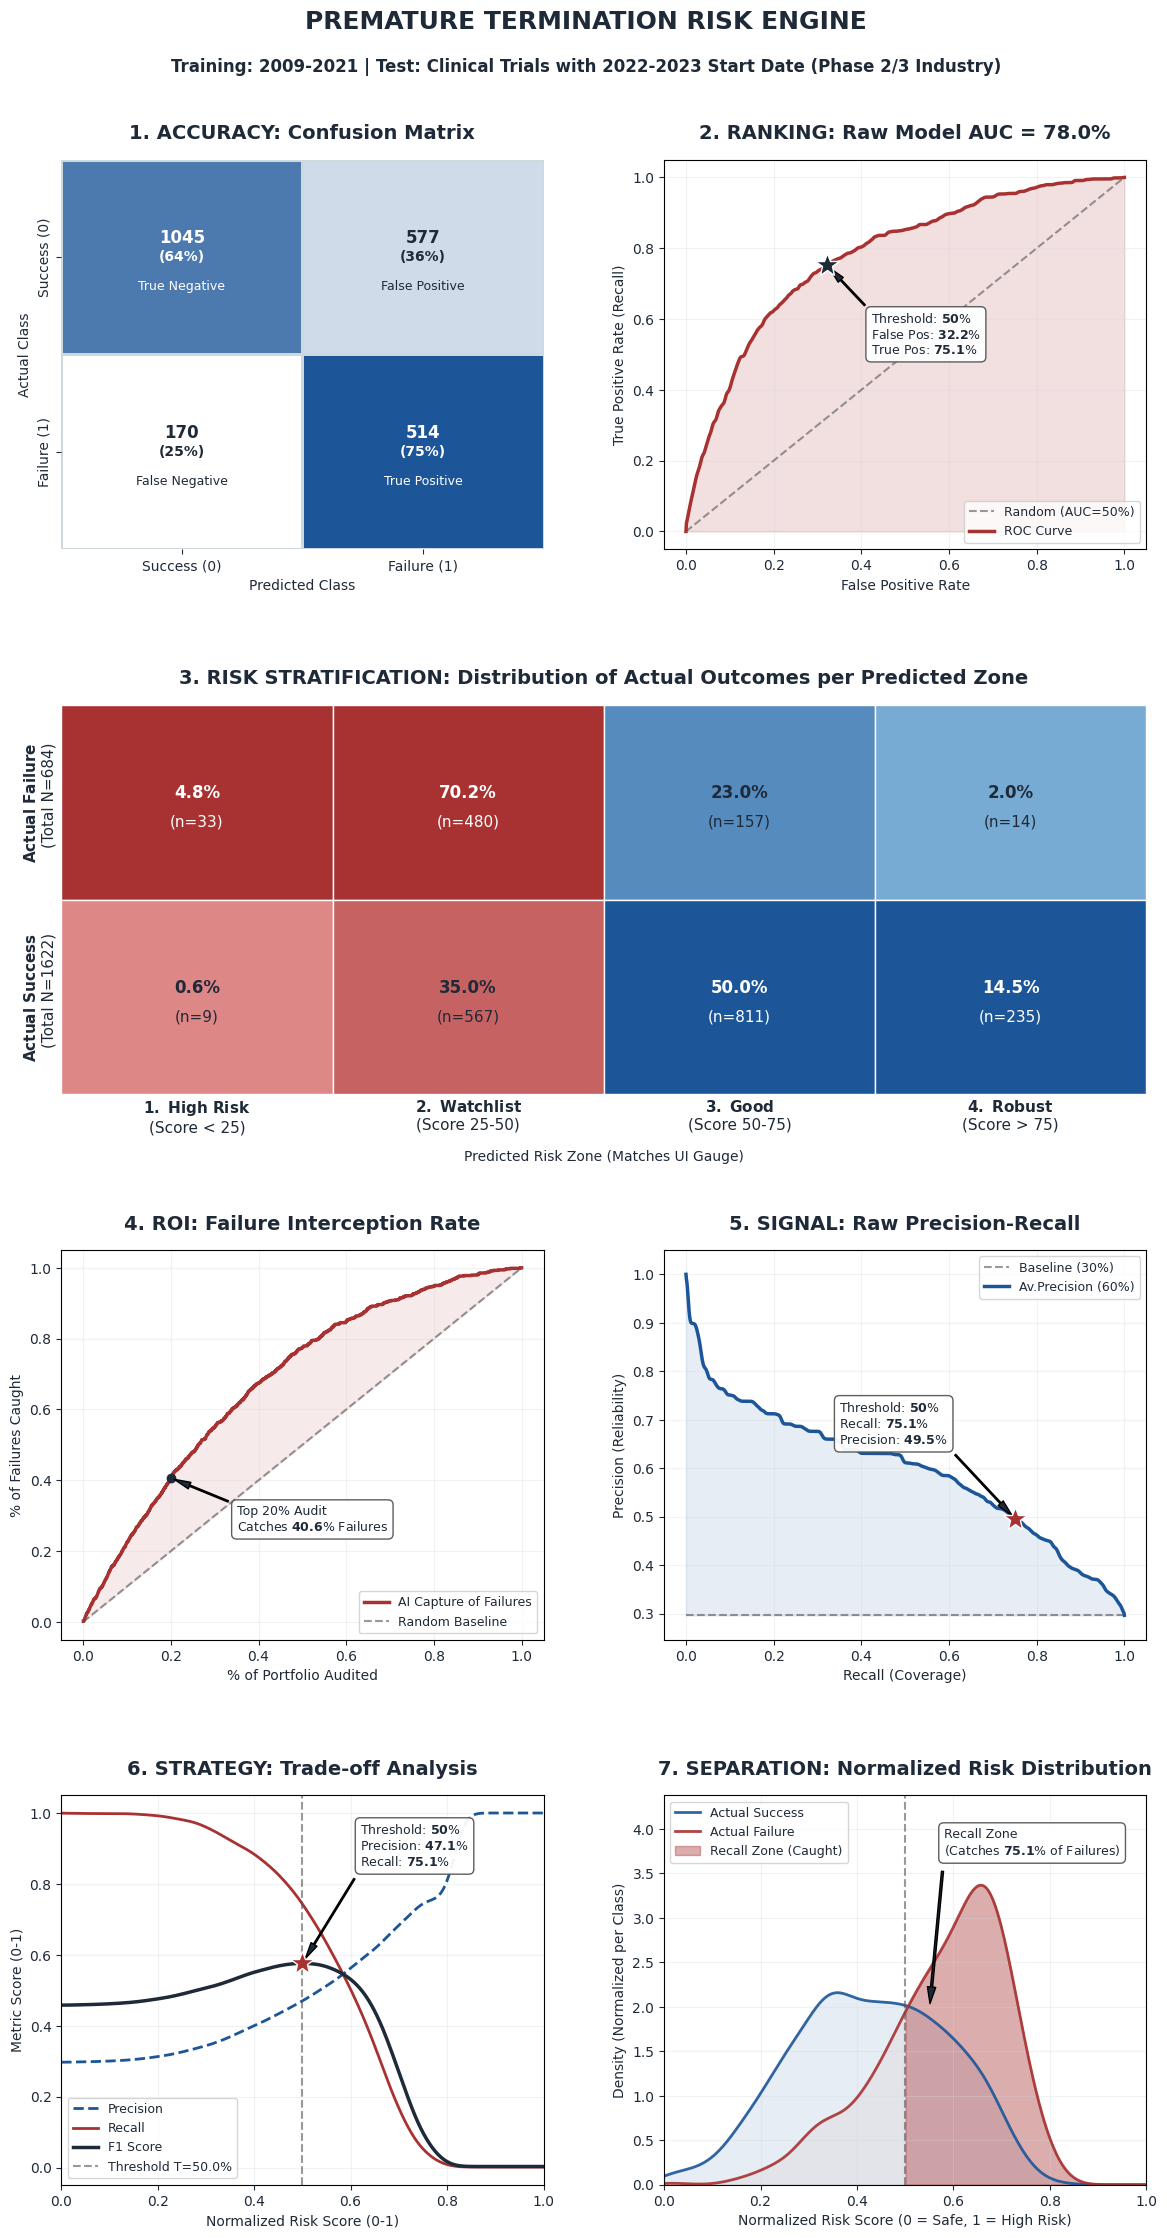

In [18]:
# <REF:PERF_VIS_CODE>
def plot_universal_professional_dashboard(y_true, y_scores_norm, y_scores_raw=None, threshold=0.5):
    """
    Generates the UI-Matched Data Science Dashboard.
    """
    if y_scores_raw is None:
        y_scores_raw = y_scores_norm

    # --- LAYOUT SETUP ---
    fig = plt.figure(figsize=(14, 25), facecolor='white')

    # Global Title
    fig.suptitle("PREMATURE TERMINATION RISK ENGINE",
                 fontsize=18, fontweight='bold', color=UI_COLORS['text_main'], y=0.98)
    fig.text(0.5, 0.955, "Training: 2009-2021 | Test: Clinical Trials with 2022-2023 Start Date (Phase 2/3 Industry)",
             ha='center', fontsize=12, fontweight='bold', color=UI_COLORS['text_main'])

    # Grid Layout
    gs = fig.add_gridspec(4, 2, hspace=0.4, wspace=0.25, top=0.92)

    ax1 = fig.add_subplot(gs[0, 0]) # Accuracy
    ax2 = fig.add_subplot(gs[0, 1]) # ROC
    ax3 = fig.add_subplot(gs[1, :]) # Matrix (Full Width)
    ax4 = fig.add_subplot(gs[2, 0]) # ROI
    ax5 = fig.add_subplot(gs[2, 1]) # PR Curve
    ax6 = fig.add_subplot(gs[3, 0]) # Strategy
    ax7 = fig.add_subplot(gs[3, 1]) # Separation

    # ==========================================================================
    # METRICS CALCULATION
    # ==========================================================================

    # 1. HYBRID STRATEGY (The actual Decision Policy)
    y_pred_hyb = (y_scores_norm >= threshold).astype(int)
    cm_hyb = confusion_matrix(y_true, y_pred_hyb)
    tn_h, fp_h, fn_h, tp_h = cm_hyb.ravel()

    rec_hyb = tp_h / (tp_h + fn_h) if (tp_h + fn_h) > 0 else 0
    prec_hyb = tp_h / (tp_h + fp_h) if (tp_h + fp_h) > 0 else 0
    fpr_hyb = fp_h / (tn_h + fp_h) if (tn_h + fp_h) > 0 else 0

    # 2. RAW MODEL FRONTIER (The Intelligence Curve)
    fpr_raw_arr, tpr_raw_arr, _ = roc_curve(y_true, y_scores_raw)
    p_raw_arr, r_raw_arr, _ = precision_recall_curve(y_true, y_scores_raw)

    # To place the star ON the line and keep numbers consistent with Panel 1:
    idx_roc = np.argmin(np.abs(tpr_raw_arr - rec_hyb))
    star_fpr = fpr_raw_arr[idx_roc]
    star_rec = tpr_raw_arr[idx_roc]

    idx_pr = np.argmin(np.abs(r_raw_arr - rec_hyb))
    star_prec = p_raw_arr[idx_pr]

    # ==========================================================================
    # PANEL 1: ACCURACY (Confusion Matrix)
    # ==========================================================================
    cm_perc = cm_hyb.astype('float') / cm_hyb.sum(axis=1)[:, np.newaxis]
    names = [['True Negative', 'False Positive'], ['False Negative', 'True Positive']]

    sns.heatmap(cm_perc, fmt="", cmap=cmap_conf, ax=ax1, cbar=False,
                linewidths=1, linecolor=UI_COLORS['grid_grey'])

    for i in range(2):
        for j in range(2):
            text_col = "white" if cm_perc[i, j] > 0.5 else UI_COLORS['text_main']
            ax1.text(j + 0.5, i + 0.4, f"{cm_hyb[i, j]}",
                     ha='center', va='center', color=text_col, fontsize=12, fontweight='bold')
            ax1.text(j + 0.5, i + 0.5, f"({cm_perc[i, j]:.0%})",
                     ha='center', va='center', color=text_col, fontsize=10, fontweight='bold')
            ax1.text(j + 0.5, i + 0.65, f"{names[i][j]}",
                     ha='center', va='center', color=text_col, fontsize=9)

    ax1.set_title(f"1. ACCURACY: Confusion Matrix", pad=15, color=UI_COLORS['text_main'])
    ax1.set_xlabel("Predicted Class")
    ax1.set_ylabel("Actual Class")
    ax1.set_xticklabels(['Success (0)', 'Failure (1)'])
    ax1.set_yticklabels(['Success (0)', 'Failure (1)'])

    # ==========================================================================
    # PANEL 2: RANKING (ROC Curve)
    # ==========================================================================
    roc_auc = auc(fpr_raw_arr, tpr_raw_arr)
    fpr_grid = np.linspace(0, 1, 1000)
    tpr_smooth = gaussian_filter1d(np.interp(fpr_grid, fpr_raw_arr, tpr_raw_arr), sigma=2)
    tpr_smooth[0], tpr_smooth[-1] = 0.0, 1.0

    ax2.plot([0, 1], [0, 1], label='Random (AUC=50%)', **ref_line_style)
    ax2.plot(fpr_grid, tpr_smooth, color=UI_COLORS['fail_deep'], lw=2.5, label=f'ROC Curve')
    ax2.fill_between(fpr_grid, tpr_smooth, alpha=0.15, color=UI_COLORS['fail_deep'])

    # Star on the line matching Strategy Recall
    ax2.plot(star_fpr, star_rec, marker='*', ms=18, color=UI_COLORS['text_main'],
             zorder=10, markeredgecolor='white')

    # FIXED: Explicit \n inside the f-string for visual line breaks
    note = (fr"Threshold: $\mathbf{{{threshold*100:.0f}}}$%" + "\n"
            fr"False Pos: $\mathbf{{{star_fpr*100:.1f}}}$%" + "\n"
            fr"True Pos: $\mathbf{{{star_rec*100:.1f}}}$%")
    ax2.annotate(note, xy=(star_fpr, star_rec), xytext=(star_fpr+0.1, star_rec-0.25),
                 arrowprops=arrow_style, bbox=box_style, fontsize=9)

    ax2.set_title(f"2. RANKING: Raw Model AUC = {roc_auc:.1%}", pad=15)
    ax2.set_xlabel("False Positive Rate")
    ax2.set_ylabel("True Positive Rate (Recall)")
    ax2.legend(loc="lower right", frameon=True, fontsize=9)
    ax2.grid(True)

    # ==========================================================================
    # PANEL 3: RISK STRATIFICATION (VIBRANT GRADIENTS)
    # ==========================================================================
    df_matrix = pd.DataFrame({'target': y_true, 'prob': y_scores_norm})

    conditions = [
        (df_matrix['prob'] > 0.75),
        (df_matrix['prob'] > 0.50) & (df_matrix['prob'] <= 0.75),
        (df_matrix['prob'] > 0.25) & (df_matrix['prob'] <= 0.50),
        (df_matrix['prob'] <= 0.25)
    ]
    choices = ["1. High Risk", "2. Watchlist", "3. Good", "4. Robust"]
    df_matrix['Zone'] = np.select(conditions, choices, default="4. Robust")

    total_failures = df_matrix[df_matrix['target'] == 1].shape[0]
    total_successes = df_matrix[df_matrix['target'] == 0].shape[0]

    # FIXED: \n for proper headers
    row_labels_map = {
        0: fr"$\mathbf{{Actual\ Success}}$" + f"\n(Total N={total_successes})",
        1: fr"$\mathbf{{Actual\ Failure}}$" + f"\n(Total N={total_failures})"
    }
    df_matrix['target_label'] = df_matrix['target'].map(row_labels_map)

    col_order = choices
    row_order = [
        fr"$\mathbf{{Actual\ Failure}}$" + f"\n(Total N={total_failures})",
        fr"$\mathbf{{Actual\ Success}}$" + f"\n(Total N={total_successes})"
    ]

    matrix_pct = pd.crosstab(index=df_matrix['target_label'], columns=df_matrix['Zone'], normalize='index')[col_order] * 100
    matrix_counts = pd.crosstab(index=df_matrix['target_label'], columns=df_matrix['Zone'])[col_order]

    matrix_pct = matrix_pct.reindex(row_order).fillna(0)
    matrix_counts = matrix_counts.reindex(row_order).fillna(0)

    # FIXED: \n for zone descriptions
    detailed_labels = [
        fr"$\mathbf{{1.\ High\ Risk}}$" + "\n(Score < 25)",
        fr"$\mathbf{{2.\ Watchlist}}$" + "\n(Score 25-50)",
        fr"$\mathbf{{3.\ Good}}$" + "\n(Score 50-75)",
        fr"$\mathbf{{4.\ Robust}}$" + "\n(Score > 75)"
    ]

    rows = matrix_pct.index
    cols = matrix_pct.columns
    n_rows = len(rows)
    n_cols = len(cols)

    ax3.set_xlim(0, n_cols)
    ax3.set_ylim(0, n_rows)

    for j, col_label in enumerate(cols):
        if "High Risk" in col_label or "Watchlist" in col_label:
            current_cmap = cmap_fail
        else:
            current_cmap = cmap_succ

        val_fail = matrix_pct.loc[row_order[0], col_label]
        val_succ = matrix_pct.loc[row_order[1], col_label]
        max_val = max(val_fail, val_succ)
        if max_val == 0: max_val = 1.0

        for i, row_label in enumerate(rows):
            count = int(matrix_counts.loc[row_label, col_label])
            pct_display = matrix_pct.loc[row_label, col_label]

            intensity = pct_display / max_val
            # Start from 0.15 to keep light colors visible but clear
            rect_color = current_cmap(0.15 + (0.85 * intensity))

            rect = patches.Rectangle((j, n_rows - 1 - i), 1, 1, linewidth=1,
                                     edgecolor='white', facecolor=rect_color)
            ax3.add_patch(rect)

            text_color = 'white' if intensity > 0.5 else UI_COLORS['text_main']

            ax3.text(j + 0.5, n_rows - 1 - i + 0.55, f"{pct_display:.1f}%",
                     ha='center', va='center', fontsize=12, fontweight='bold', color=text_color)
            ax3.text(j + 0.5, n_rows - 1 - i + 0.40, f"(n={count})",
                     ha='center', va='center', fontsize=11, fontweight='normal', color=text_color)

    ax3.set_xticks(np.arange(n_cols) + 0.5)
    ax3.set_xticklabels(detailed_labels, fontsize=11)
    ax3.set_yticks(np.arange(n_rows) + 0.5)
    ax3.set_yticklabels(rows[::-1], fontsize=11, rotation=90, va='center')
    ax3.set_title("3. RISK STRATIFICATION: Distribution of Actual Outcomes per Predicted Zone", pad=15)
    ax3.set_xlabel("Predicted Risk Zone (Matches UI Gauge)", labelpad=10)
    for spine in ax3.spines.values():
        spine.set_visible(False)
    ax3.tick_params(length=0)

    # ==========================================================================
    # PANEL 4: ROI
    # ==========================================================================
    data = pd.DataFrame({'target': y_true, 'prob': y_scores_norm}).sort_values('prob', ascending=False)
    data['cum_pop'] = np.arange(1, len(data) + 1) / len(data)
    data['cum_gain'] = data['target'].cumsum() / data['target'].sum()

    ax4.plot(data['cum_pop'], data['cum_gain'], color=UI_COLORS['fail_deep'], lw=2.5, label='AI Capture of Failures')
    ax4.plot([0, 1], [0, 1], label='Random Baseline', **ref_line_style)
    ax4.fill_between(data['cum_pop'], data['cum_pop'], data['cum_gain'], color=UI_COLORS['fail_deep'], alpha=0.1)

    idx_20 = (data['cum_pop'] - 0.20).abs().idxmin()
    gain_20 = data.loc[idx_20, 'cum_gain']
    ax4.plot(0.20, gain_20, 'o', color=UI_COLORS['text_main'], ms=6)

    # FIXED: \n for ROI note
    ax4.annotate(fr"Top 20% Audit" + "\n" + fr"Catches $\mathbf{{{gain_20*100:.1f}}}$% Failures",
                 xy=(0.20, gain_20), xytext=(0.35, gain_20 - 0.15),
                 arrowprops=arrow_style, bbox=box_style, fontsize=9)
    ax4.set_title("4. ROI: Failure Interception Rate", pad=15)
    ax4.set_xlabel("% of Portfolio Audited")
    ax4.set_ylabel("% of Failures Caught")
    ax4.legend(loc="lower right", frameon=True, fontsize=9)
    ax4.grid(True)

    # ==========================================================================
    # PANEL 5: SIGNAL
    # ==========================================================================
    ap = average_precision_score(y_true, y_scores_raw)
    base = y_true.mean()
    r_sort = np.argsort(r_raw_arr)
    p_mono = IsotonicRegression(increasing=False).fit_transform(r_raw_arr[r_sort], p_raw_arr[r_sort])
    r_dense = np.linspace(0, 1, 1000)
    p_smooth = gaussian_filter1d(np.interp(r_dense, r_raw_arr[r_sort], p_mono), sigma=3)
    p_smooth[0], p_smooth[-1] = 1.0, base

    ax5.plot([0, 1], [base, base], label=f'Baseline ({base:.0%})', **ref_line_style)
    ax5.plot(r_dense, p_smooth, color=UI_COLORS['succ_deep'], lw=2.5, label=f'Av.Precision ({ap:.0%})')
    ax5.fill_between(r_dense, p_smooth, base, color=UI_COLORS['succ_deep'], alpha=0.1)

    # Star on the line matching Strategy Recall
    ax5.plot(star_rec, star_prec, marker='*', ms=18, color=UI_COLORS['fail_deep'],
             zorder=10, markeredgecolor='white')

    # FIXED: Explicit \n for PR note
    note_pr = (fr"Threshold: $\mathbf{{{threshold*100:.0f}}}$%" + "\n"
               fr"Recall: $\mathbf{{{star_rec*100:.1f}}}$%" + "\n"
               fr"Precision: $\mathbf{{{star_prec*100:.1f}}}$%")
    ax5.annotate(note_pr, xy=(star_rec, star_prec), xytext=(0.35, 0.65),
                 arrowprops=arrow_style, bbox=box_style, fontsize=9)
    ax5.set_title("5. SIGNAL: Raw Precision-Recall", pad=15)
    ax5.set_xlabel("Recall (Coverage)")
    ax5.set_ylabel("Precision (Reliability)")
    ax5.set_ylim(base-0.05, 1.05)
    ax5.legend(loc="upper right", frameon=True, fontsize=9)
    ax5.grid(True)

    # ==========================================================================
    # PANEL 6: STRATEGY
    # ==========================================================================
    p_trade, r_trade, t_trade = precision_recall_curve(y_true, y_scores_norm)
    p_trade, r_trade = p_trade[:-1], r_trade[:-1]
    t_grid = np.linspace(0, 1, 500)
    p_smooth_line = gaussian_filter1d(np.interp(t_grid, t_trade, IsotonicRegression(increasing=True).fit_transform(t_trade, p_trade)), sigma=10)
    r_smooth_line = gaussian_filter1d(np.interp(t_grid, t_trade, IsotonicRegression(increasing=False).fit_transform(t_trade, r_trade)), sigma=10)
    f1_smooth_line = 2*(p_smooth_line*r_smooth_line)/(p_smooth_line+r_smooth_line+1e-8)

    ax6.plot(t_grid, p_smooth_line, color=UI_COLORS['succ_deep'], linestyle='--', lw=2, label="Precision")
    ax6.plot(t_grid, r_smooth_line, color=UI_COLORS['fail_deep'], linestyle='-', lw=2, label="Recall")
    ax6.plot(t_grid, f1_smooth_line, color=UI_COLORS['text_main'], linestyle='-', lw=2.5, label="F1 Score")
    ax6.axvline(threshold, label=f'Threshold T={threshold:.1%}', **ref_line_style)

    idx_thresh = np.argmin(np.abs(t_grid - threshold))
    f1_at_thresh = f1_smooth_line[idx_thresh]
    ax6.plot(threshold, f1_at_thresh, marker='*', ms=18, color=UI_COLORS['fail_deep'],
             zorder=10, markeredgecolor='white')

    # FIXED: Explicit \n for Strategy note
    strat_text = (fr"Threshold: $\mathbf{{{threshold*100:.0f}}}$%" + "\n"
                  fr"Precision: $\mathbf{{{prec_hyb*100:.1f}}}$%" + "\n"
                  fr"Recall: $\mathbf{{{rec_hyb*100:.1f}}}$%")
    ax6.annotate(strat_text, xy=(threshold, f1_at_thresh), xytext=(0.62, 0.85),
                 arrowprops=arrow_style, bbox=box_style, fontsize=9)
    ax6.set_title("6. STRATEGY: Trade-off Analysis", pad=15)
    ax6.set_xlabel("Normalized Risk Score (0-1)")
    ax6.set_ylabel("Metric Score (0-1)")
    ax6.legend(loc="lower left", frameon=True, fontsize=9)
    ax6.grid(True)
    ax6.set_xlim(0, 1.0)

    # ==========================================================================
    # PANEL 7: SEPARATION
    # ==========================================================================
    x_grid = np.linspace(0, 1, 500)
    kde_succ = gaussian_kde(y_scores_norm[y_true == 0])
    kde_fail = gaussian_kde(y_scores_norm[y_true == 1])
    y_succ_balanced = kde_succ(x_grid)
    y_fail_balanced = kde_fail(x_grid)

    ax7.plot(x_grid, y_succ_balanced, color=UI_COLORS['succ_deep'], alpha=0.9, lw=2, label='Actual Success')
    ax7.fill_between(x_grid, 0, y_succ_balanced, color=UI_COLORS['succ_deep'], alpha=0.1)
    ax7.plot(x_grid, y_fail_balanced, color=UI_COLORS['fail_deep'], alpha=0.9, lw=2, label='Actual Failure')
    ax7.fill_between(x_grid, 0, y_fail_balanced, where=(x_grid >= threshold),
                     color=UI_COLORS['fail_deep'], alpha=0.4, label='Recall Zone (Caught)')
    ax7.fill_between(x_grid, 0, y_fail_balanced, where=(x_grid < threshold),
                     color=UI_COLORS['fail_deep'], alpha=0.05)
    ax7.axvline(threshold, **ref_line_style)

    max_density = max(y_succ_balanced.max(), y_fail_balanced.max())
    ax7.set_ylim(0, max_density * 1.3)

    # FIXED: \n for Separation note
    ax7.annotate(fr"Recall Zone" + "\n" + fr"(Catches $\mathbf{{{rec_hyb*100:.1f}}}$% of Failures)",
                        xy=(threshold + 0.05, y_fail_balanced[np.argmin(np.abs(x_grid - threshold))]),
                        xytext=(0.58, max_density * 1.1),
                        arrowprops=dict(facecolor=UI_COLORS['text_main'], shrink=0.05, width=1.5, headwidth=6),
                        bbox=box_style, fontsize=9)
    ax7.set_title("7. SEPARATION: Normalized Risk Distribution", pad=15)
    ax7.set_xlabel("Normalized Risk Score (0 = Safe, 1 = High Risk)")
    ax7.set_ylabel("Density (Normalized per Class)")
    ax7.legend(loc="upper left", frameon=True, fontsize=9)
    ax7.grid(True)
    ax7.set_xlim(0, 1.0)

    plt.show()

# --- EXECUTE ---
print(">>> Rendering Final UI-Matched Dashboard...")
# --- SYNC LOGIC: Forced Data Refresh ---
# We re-patch test_results here to ensure strategy changes flow into the plots.
test_results = X_test.copy()
test_results['target'] = y_test
test_results['proba_1'] = y_prob
test_results['risk_score_norm'] = 1.0 - (df_scores['Clinical_Score'] / 100.0)

plot_universal_professional_dashboard(
    y_true=test_results['target'],
    y_scores_norm=test_results['risk_score_norm'],
    y_scores_raw=test_results['proba_1'],
    threshold=0.5
)
# <REF:/PERF_VIS_CODE>


#### <REF:UI_VIS>
> #### **14. Individual Trial Profiler: Production APP UI Snapshot**

This module demonstrates the individual-level output used in the production application. The **Clinical Success Score** is presented via a vibrant gauge, providing instant visual context—from 'High Risk' (Red) to 'Robust' (Gold)—to support rapid, high-confidence decision-making.


In [19]:
# <REF:UI_VIS_CODE>
Trial_Example = 350

print(f"\n>>> FINAL STEP: UI VISUALIZATION SNAPSHOT FOR TRIAL ID {Trial_Example}...")


import plotly.graph_objects as go
import pandas as pd
import numpy as np
import re
import textwrap

# ==============================================================================
# 0. UNIFIED STYLE CONFIGURATION (VIBRANT PROFESSIONAL)
# ==============================================================================
STYLE_CONFIG = {
    "font_family": "Arial",
    "font_size_header": 16,
    "font_size_body": 14,
    "font_color": "#1f2a38",
    "colors": {
        "red_deep":   (168, 50, 50),
        "red_soft":   (240, 163, 163),
        "grey_warm":  (242, 244, 248),
        "blue_soft":  (154, 203, 232),
        "blue_deep":  (28, 86, 153),
        "therapeutic_grey": "#CFD8DC",
        "separator_white": "white"
    }
}

def get_rgb_str(rgb_tuple):
    return f"rgb({rgb_tuple[0]},{rgb_tuple[1]},{rgb_tuple[2]})"

def interpolate_color(c1, c2, ratio):
    r = int(c1[0] + (c2[0] - c1[0]) * ratio)
    g = int(c1[1] + (c2[1] - c1[1]) * ratio)
    b = int(c1[2] + (c2[2] - c1[2]) * ratio)
    return (r, g, b)

def mix_white(rgb, factor=0.7):
    r, g, b = rgb
    new_r = int(r + (255 - r) * factor)
    new_g = int(g + (255 - g) * factor)
    new_b = int(b + (255 - b) * factor)
    return (new_r, new_g, new_b)

def fmt_header(text, value, txt_color="black", split=False):
    label = f"{text}<br>({value:+.1f}%)" if split else f"{text} ({value:+.1f}%)"
    return f"<span style='font-size:14px; font-weight:bold; color:{txt_color}'>{label}</span>"

# ==============================================================================
# 1. GAUGE CHART
# ==============================================================================
print("\n=== STEP 14: CLINICAL SCORE GAUGE (VIBRANT) ===")

def plot_risk_gauge(score_val):
    steps = []
    c = STYLE_CONFIG["colors"]
    for i in range(100):
        if i < 25: color = interpolate_color(c["red_deep"], c["red_soft"], i / 25.0)
        elif i < 50: color = interpolate_color(c["red_soft"], c["grey_warm"], (i - 25) / 25.0)
        elif i < 75: color = interpolate_color(c["grey_warm"], c["blue_soft"], (i - 50) / 25.0)
        else: color = interpolate_color(c["blue_soft"], c["blue_deep"], (i - 75) / 25.0)
        steps.append({'range': [i, i + 1], 'color': get_rgb_str(color)})
    for sep in [25, 50, 75]: steps.append({'range': [sep - 0.5, sep + 0.5], 'color': 'white'})

    fig = go.Figure(go.Indicator(
        mode="gauge+number", value=score_val,
        number={"valueformat": ".1f", "font": {"size": 52, "color": STYLE_CONFIG["font_color"], "family": STYLE_CONFIG["font_family"], "weight": "bold"}},
        domain={"x": [0, 1], "y": [0, 1]},
        gauge={
            "axis": {"range": [0, 100], "tickmode": "array", "tickvals": [0, 25, 50, 75, 100], "tickfont": {"size": 14, "color": "#555555", "family": "Arial", "weight": "bold"}},
            "bar": {"color": "rgba(0,0,0,0)"}, "bgcolor": "white", "borderwidth": 0, "steps": steps,
            "threshold": {"line": {"color": STYLE_CONFIG["font_color"], "width": 5}, "thickness": 0.75, "value": score_val},
        },
    ))
    fig.update_layout(margin=dict(l=35, r=35, t=40, b=10), height=220, paper_bgcolor="white", hovermode=False)
    return fig

# ==============================================================================
# 2. IMPACT BAR CHART
# ==============================================================================
print("\n=== STEP 14: INDIVIDUAL TRIAL PROFILER (VIBRANT EDGES) ===")

def get_pillar_impacts(df_scores, trial_index):
    meta_cols = ['Clinical_Score', 'Therapeutic_Area', 'Phase', 'Internal_Score_Raw', 'Zone', 'CALIBRATION_OFFSET']
    pillar_cols = [c for c in df_scores.columns if c not in meta_cols]
    row = df_scores.loc[trial_index, pillar_cols].copy()
    df_impact = pd.DataFrame({'Pillar': row.index, 'Impact': row.values})
    df_impact['Pillar_Clean'] = df_impact['Pillar'].apply(lambda x: re.sub(r'^\d+\.\s*', '', x))
    df_impact['Label'] = df_impact['Impact'].apply(lambda x: f"{x:+.1f}%")
    return df_impact.sort_values(by='Impact', ascending=True)

def plot_impact_bar(df_impact, trial_id, score):
    max_val = df_impact['Impact'].abs().max()
    limit, BAR_WIDTH, SLICE_STEP, GLOBAL_MAX_SCALE = max_val * 1.35, 0.75, 0.08, 4.0
    c = STYLE_CONFIG["colors"]
    fig = go.Figure()
    for i in range(int(np.ceil(max_val / SLICE_STEP))):
        pos = i * SLICE_STEP
        widths, colors, texts = [], [], []
        for val in df_impact['Impact']:
            abs_v = abs(val)
            if pos >= abs_v: w, is_tip = 0, False
            elif pos + SLICE_STEP > abs_v: w, is_tip = abs_v - pos, True
            else: w, is_tip = SLICE_STEP, False
            widths.append(-w if val < 0 else w)
            texts.append(f"{val:+.1f}%" if is_tip else None)
            ratio = min((pos + abs(w)/2) / GLOBAL_MAX_SCALE, 1.0) ** 0.5
            if val >= 0:
                final_rgb = interpolate_color(c["grey_warm"], c["blue_soft"], ratio*2) if ratio < 0.5 else interpolate_color(c["blue_soft"], c["blue_deep"], (ratio-0.5)*2)
            else:
                final_rgb = interpolate_color(c["grey_warm"], c["red_soft"], ratio*2) if ratio < 0.5 else interpolate_color(c["red_soft"], c["red_deep"], (ratio-0.5)*2)
            colors.append(get_rgb_str(final_rgb))
        fig.add_trace(go.Bar(y=df_impact['Pillar_Clean'], x=widths, orientation='h', width=BAR_WIDTH, marker=dict(color=colors, line=dict(width=0)), text=texts, textposition='outside', textfont=dict(size=12, color="black"), hoverinfo='skip', showlegend=False))
    fig.add_vline(x=0, line_width=1, line_color="#333333")
    fig.update_layout(barmode='relative', xaxis=dict(showticklabels=False, range=[-limit, limit]), yaxis=dict(automargin=True), margin=dict(l=10, r=10, t=50, b=10), height=300, paper_bgcolor="white", plot_bgcolor="white")
    return fig

# ==============================================================================
# 3. TREEMAP
# ==============================================================================
print("\n=== STEP 14: VISUALIZATION (VIBRANT TREEMAP) ===")

def plot_smart_treemap(shap_values, feature_names, trial_index, taxonomy, gain_factor, df_scores, df_raw):
    # ROBUST DATA ACCESS
    if df_raw.index.name != 'nct_id':
        if 'nct_id' in df_raw.columns:
            trial_data = df_raw[df_raw['nct_id'] == trial_index].iloc[0]
        else:
            return go.Figure()
    else:
        trial_data = df_raw.loc[trial_index]

    try:
        pos_idx = df_scores.index.get_loc(trial_index)
        row_shap = shap_values[pos_idx]
        calib_credit = df_scores.loc[trial_index, "CALIBRATION_OFFSET"]
    except:
        return go.Figure()

    nodes, node_sums, c, leaf_data = {}, {"ALL_DRIVERS": 0.0}, STYLE_CONFIG["colors"], []
    nodes["ALL_DRIVERS"] = {"parent": "", "label": "ALL DRIVERS", "color": "#FFFFFF", "value": 0}

    for pillar_raw, topics in taxonomy.items():
        pillar_clean = pillar_raw.split(". ")[-1]
        p_id = f"PILLAR_{pillar_clean}"
        nodes[p_id] = {"parent": "ALL_DRIVERS", "label": pillar_clean.upper(), "color": "#ECEFF1", "value": 0}
        node_sums[p_id] = 0.0

        for subtopic, details in topics.items():
            f_keys_list, f_labels_list = details["features"], details["feature_labels"]
            impact, feat_strings = 0.0, []

            for f_keys, f_label in zip(f_keys_list, f_labels_list):
                if not isinstance(f_keys, list): f_keys = [f_keys]
                sub_impact, val_parts = 0.0, []

                for k in f_keys:
                    # 1. Calculation
                    if k == "CALIBRATION_OFFSET":
                        sub_impact += calib_credit
                        val_parts.append(str(trial_data.get("therapeutic_area_ui", "N/A")))
                    else:
                        # Find SHAP (if active)
                        idx_f = next((i for i, f in enumerate(feature_names) if f == k), None)
                        if idx_f is not None:
                            sub_impact += (row_shap[idx_f] * gain_factor * -1)

                        # 2. Value Lookup (even if SHAP is 0/disabled)
                        # Remove prefixes to find raw column name
                        raw_k = k.replace("ordinal__", "").replace("target__", "").replace("num_arms__", "").replace("num_duration__", "")
                        ui_col = raw_k.replace("_ml", "_ui")
                        if "gbd_cause_id_3" in raw_k: ui_col = "gbd_indication_name"

                        val = trial_data.get(ui_col, "N/A")
                        if isinstance(val, float): val = f"{val:.1f}"
                        val_parts.append(str(val))

                impact += sub_impact
                feat_strings.append(f"{f_label}: <b>{' / '.join(val_parts)}</b>")

            ratio = max(0.15, min(abs(impact) / 8.0, 1.0))
            color = interpolate_color(c["blue_soft"], c["blue_deep"], ratio) if impact >= 0 else interpolate_color(c["red_soft"], c["red_deep"], ratio)

            label_html = (f"<span style='font-size:15px; font-weight:bold; color:white'>{subtopic}</span>"
                          f"<br><span style='font-size:14px; color:white'>{impact:+.1f}%</span>"
                          f"<br><br><span style='font-size:11px; color:white'>• {'<br>• '.join(feat_strings)}</span>")

            leaf_id = f"{p_id}_{subtopic}"
            node_sums[p_id] += impact
            node_sums["ALL_DRIVERS"] += impact
            leaf_data.append({"id": leaf_id, "parent": p_id, "label": label_html, "color": get_rgb_str(color), "value": max(0.5, abs(impact))})

    for p_id, val in node_sums.items():
        if p_id == "ALL_DRIVERS": nodes[p_id]["label"] = fmt_header("ALL DRIVERS", val)
        else:
            nodes[p_id]["label"] = fmt_header(nodes[p_id]["label"], val)
            nodes[p_id]["color"] = get_rgb_str(mix_white(interpolate_color(c["blue_soft" if val >= 0 else "red_soft"], c["blue_deep" if val >= 0 else "red_deep"], min(abs(val)/8.0, 1.0))))

    for item in leaf_data: nodes[item["id"]] = item
    ids = list(nodes.keys())
    fig = go.Figure(go.Treemap(ids=ids, labels=[nodes[k]["label"] for k in ids], parents=[nodes[k]["parent"] for k in ids], values=[nodes[k]["value"] for k in ids], marker=dict(colors=[nodes[k]["color"] for k in ids], line=dict(width=1, color="white")), textinfo="label", textposition="top left"))
    fig.update_layout(margin=dict(t=34, l=15, r=15, b=15), height=600, paper_bgcolor="white", hovermode=False)
    return fig

# ==============================================================================
# 4. EXECUTION
# ==============================================================================
# Set index for lookup parity
if df_full.index.name != 'nct_id':
    df_full = df_full.set_index('nct_id')

target_idx = df_scores.index[Trial_Example]
score_val = df_scores.loc[target_idx, 'Clinical_Score']

fig_gauge = plot_risk_gauge(score_val)
fig_gauge.show()

fig_bar = plot_impact_bar(get_pillar_impacts(df_scores, target_idx), target_idx, score_val)
fig_bar.show()

fig_tree = plot_smart_treemap(shap_values, feature_names, target_idx, RISK_TAXONOMY, GAIN_FACTOR, df_scores, df_full)
fig_tree.show()

# <REF:/UI_VIS_CODE>



>>> FINAL STEP: UI VISUALIZATION SNAPSHOT FOR TRIAL ID 350...

=== STEP 14: CLINICAL SCORE GAUGE (VIBRANT) ===

=== STEP 14: INDIVIDUAL TRIAL PROFILER (VIBRANT EDGES) ===

=== STEP 14: VISUALIZATION (VIBRANT TREEMAP) ===


#### <REF:ROLLING_VALID>
> #### **15. Rolling Validation: Overall Model Robustness Check**

**Objective**
This module executes a rigorous **Time-Series Cross-Validation** to assess the model's temporal stability and generalization capabilities across the full 2009–2022 timeline.

**Rationale**
Standard randomized Cross-Validation (K-Fold) is invalid for time-dependent data as it introduces "Look-Ahead Bias" (training on future data to predict the past). To accurately simulate real-world deployment, this module utilizes a **Rolling Origin** approach. This ensures the model is evaluated on its ability to adapt to evolving clinical standards, changing regulatory environments, and shifting baseline failure rates.

**Methodology (Step-by-Step)**

1.  **Data Unification & Sorting**
    *   **Code Reference:** `pd.concat`, `sort_values(by=['start_date'])`
    *   **Logic:** The Training and Test sets are merged and strictly ordered by `start_date`. This reconstructs the complete historical timeline of clinical trials.

2.  **Rolling Origin Splitting**
    *   **Code Reference:** `TimeSeriesSplit(n_splits=6)`
    *   **Logic:** The timeline is divided into expanding windows.
        *   *Fold 1:* Train on [2009–2011], Predict [2012].
        *   *Fold 2:* Train on [2009–2013], Predict [2014].
        *   *Result:* This simulates the model's performance as if it were retrained annually with new data.

3.  **Leakage Prevention**
    *   **Code Reference:** `cols_to_exclude`, `drop(columns=drop_cols)`
    *   **Logic:** Metadata columns required for sorting (e.g., `start_date`, `nct_id`) are explicitly removed *immediately* before the training step. This ensures the model learns solely from the blinded protocol features.

4.  **Stability Analysis (Dual-Axis Plot)**
    *   **Code Reference:** `plot_unified_stability`
    *   **Logic:** Two metrics are visualized simultaneously to contextualize performance:
        *   **Model Performance (AUC):** The primary line graph tracking predictive power over time.
        *   **Data Difficulty (Failure Rate):** The secondary axis tracking the prevalence of failure in the training set. This helps determine if performance fluctuations are due to model degradation or changes in the underlying market difficulty.

<REF:/ROLLING_VALID>


>>> Merging and Sorting Data for Unified Timeline...
    [Check] Data Sorted: 2009-01-01 00:00:00 to 2023-12-31 00:00:00
    [Check] Total Trials: 25397

>>> Starting Detailed CV (6 folds)...
Fold 1: Train[2009-01-01] -> Val[2010-11-30] AUC: 0.6541
Fold 2: Train[2009-01-01] -> Val[2012-10-15] AUC: 0.6696
Fold 3: Train[2009-01-01] -> Val[2014-09-30] AUC: 0.6994
Fold 4: Train[2009-01-01] -> Val[2016-10-20] AUC: 0.6714
Fold 5: Train[2009-01-01] -> Val[2018-12-04] AUC: 0.7056
Fold 6: Train[2009-01-01] -> Val[2021-03-29] AUC: 0.7652

FINAL TEMPORAL VALIDATION REPORT
 Fold  Train_Count  Val_Count  ROC_AUC   PR_AUC
    1         3629       3628 0.654112 0.235829
    2         7257       3628 0.669631 0.263664
    3        10885       3628 0.699388 0.301921
    4        14513       3628 0.671437 0.355029
    5        18141       3628 0.705559 0.389560
    6        21769       3628 0.765222 0.577378


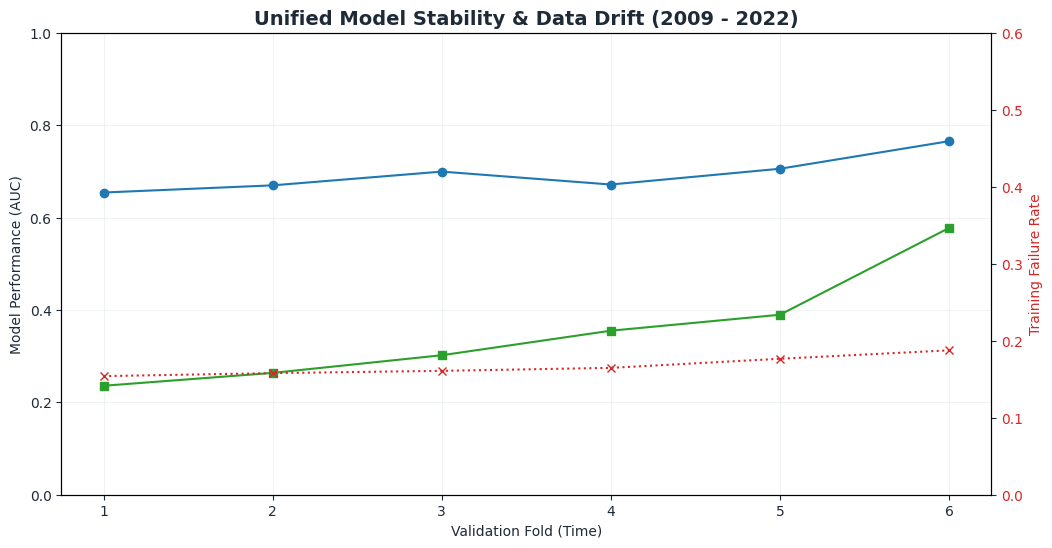

In [20]:
# <REF:ROLLING_VALID_CODE>
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.base import clone

# ==============================================================================
# STEP A: DEFINE THE ROLLING VALIDATION ENGINE
# ==============================================================================
def run_detailed_unified_cv(model_pipeline, X_train, y_train, X_test, y_test, n_splits=6):
    """
    Runs Rolling Origin CV using 'start_date' found directly inside X.
    Automatically drops 'start_date' before training to prevent leakage.
    """
    print(f">>> Merging and Sorting Data for Unified Timeline...")

    # 1. Merge and ensure clean indices
    X_full = pd.concat([X_train, X_test])
    y_full = pd.concat([y_train, y_test])

    if 'start_date' not in X_full.columns:
        raise KeyError("Column 'start_date' not found in X. Ensure Step B restoration ran.")

    # 2. Convert and Sort
    X_full['start_date'] = pd.to_datetime(X_full['start_date'], errors='coerce')
    X_full = X_full.sort_values(by=['start_date'])
    y_full = y_full.loc[X_full.index]

    print(f"    [Check] Data Sorted: {X_full['start_date'].min()} to {X_full['start_date'].max()}")
    print(f"    [Check] Total Trials: {len(X_full)}")

    tscv = TimeSeriesSplit(n_splits=n_splits)
    results = []
    cols_to_exclude = ['start_date', 'nct_id', 'therapeutic_area']

    print(f"\n>>> Starting Detailed CV ({n_splits} folds)...")

    for fold_idx, (train_ix, val_ix) in enumerate(tscv.split(X_full)):
        X_f_train_raw = X_full.iloc[train_ix]
        X_f_val_raw   = X_full.iloc[val_ix]
        y_f_train     = y_full.iloc[train_ix]
        y_f_val       = y_full.iloc[val_ix]

        meta = {
            'Fold': fold_idx + 1,
            'Train_Start': X_f_train_raw['start_date'].min(),
            'Train_End':   X_f_train_raw['start_date'].max(),
            'Train_Count': len(X_f_train_raw),
            'Train_Fail_Rate': y_f_train.mean(),
            'Val_Start': X_f_val_raw['start_date'].min(),
            'Val_End':   X_f_val_raw['start_date'].max(),
            'Val_Count': len(X_f_val_raw),
            'Val_Fail_Rate': y_f_val.mean()
        }

        # Drop Metadata before fitting
        drop_cols = [c for c in cols_to_exclude if c in X_f_train_raw.columns]
        X_f_train = X_f_train_raw.drop(columns=drop_cols)
        X_f_val   = X_f_val_raw.drop(columns=drop_cols)

        # Train Clone
        fold_model = clone(model_pipeline)
        fold_model.fit(X_f_train, y_f_train)
        y_pred_prob = fold_model.predict_proba(X_f_val)[:, 1]

        meta['ROC_AUC'] = roc_auc_score(y_f_val, y_pred_prob)
        meta['PR_AUC']  = average_precision_score(y_f_val, y_pred_prob)
        results.append(meta)

        print(f"Fold {meta['Fold']}: Train[{str(meta['Train_Start'])[:10]}] -> Val[{str(meta['Val_Start'])[:10]}] AUC: {meta['ROC_AUC']:.4f}")

    return pd.DataFrame(results)

def plot_unified_stability(cv_results):
    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax1.set_xlabel('Validation Fold (Time)')
    ax1.set_ylabel('Model Performance (AUC)')
    l1 = ax1.plot(cv_results['Fold'], cv_results['ROC_AUC'], marker='o', color='tab:blue', label='ROC-AUC')
    l2 = ax1.plot(cv_results['Fold'], cv_results['PR_AUC'], marker='s', color='tab:green', label='PR-AUC')
    ax1.set_ylim(0.0, 1.0); ax1.grid(True, alpha=0.3)
    ax2 = ax1.twinx(); ax2.set_ylabel('Training Failure Rate', color='tab:red')
    l3 = ax2.plot(cv_results['Fold'], cv_results['Train_Fail_Rate'], marker='x', color='tab:red', label='Train Fail Rate', linestyle=':')
    ax2.tick_params(axis='y', labelcolor='tab:red'); ax2.set_ylim(0.0, 0.6)
    plt.title("Unified Model Stability & Data Drift (2009 - 2022)")
    plt.show()

# ==============================================================================
# STEP B: PREPARE DATA (Restore Dates for CV)
# ==============================================================================
X_train_with_date = X_train.copy()
X_test_with_date  = X_test.copy()

# Sync with df_historical which contains the start_date column
X_train_with_date['start_date'] = df_historical.loc[X_train.index, 'start_date']
X_test_with_date['start_date']  = df_historical.loc[X_test.index, 'start_date']

# ==============================================================================
# STEP C: EXECUTE
# ==============================================================================
detailed_results = run_detailed_unified_cv(model, X_train_with_date, y_train, X_test_with_date, y_test, n_splits=6)
print("\n" + "="*80 + "\nFINAL TEMPORAL VALIDATION REPORT\n" + "="*80)
print(detailed_results[['Fold', 'Train_Count', 'Val_Count', 'ROC_AUC', 'PR_AUC']].to_string(index=False))
plot_unified_stability(detailed_results)
# <REF:/ROLLING_VALID_CODE>


#### <REF:TA_FINAL_ANALYSIS>
> #### **16. Therapeutic Area Comparative Analysis: Deep-Dive Audit**

This module provides a comprehensive audit of model performance across medical sectors. It integrates historical training statistics with modern blind-test results, allowing us to verify that our **Specialization Latch** correctly handled the unique signal-to-noise ratios of each Therapeutic Area (TA).


>>> STEP 16: COMPREHENSIVE THERAPEUTIC AREA ANALYSIS ...

=== THERAPEUTIC AREA COMPARATIVE STATISTICS (SYNCED) ===
              TA  Train N Train Fail%  Test N Test Fail%   AUC  Prec   Rec Thresh
TOTAL (Strategy)    23091       19.5%    2306      29.7% 0.780 47.1% 75.1% 0.5038
        ONCOLOGY     4594       30.8%     358      62.6% 0.620 65.3% 91.5% 0.5765
      INFECTIONS     2319       14.7%     346      21.4% 0.748 39.1% 58.1% 0.4465
       NEUROLOGY     1794       22.5%     188      33.5% 0.738 48.2% 85.7% 0.5359
GASTROINTESTINAL     1762       18.7%     129      25.6% 0.764 45.9% 84.8% 0.5197
     DERMATOLOGY     1727        9.8%     229      17.0% 0.748 27.5% 56.4% 0.3843
 MUSCULOSKELETAL     1513       17.0%     135      25.9% 0.628 33.3% 31.4% 0.5445
     RESPIRATORY     1509       13.1%     127      17.3% 0.729 24.2% 72.7% 0.4321
       METABOLIC     1461       11.2%     152      13.2% 0.630 21.4% 30.0% 0.4275
  CARDIOVASCULAR     1214       21.5%     110      29.1% 0.720 42

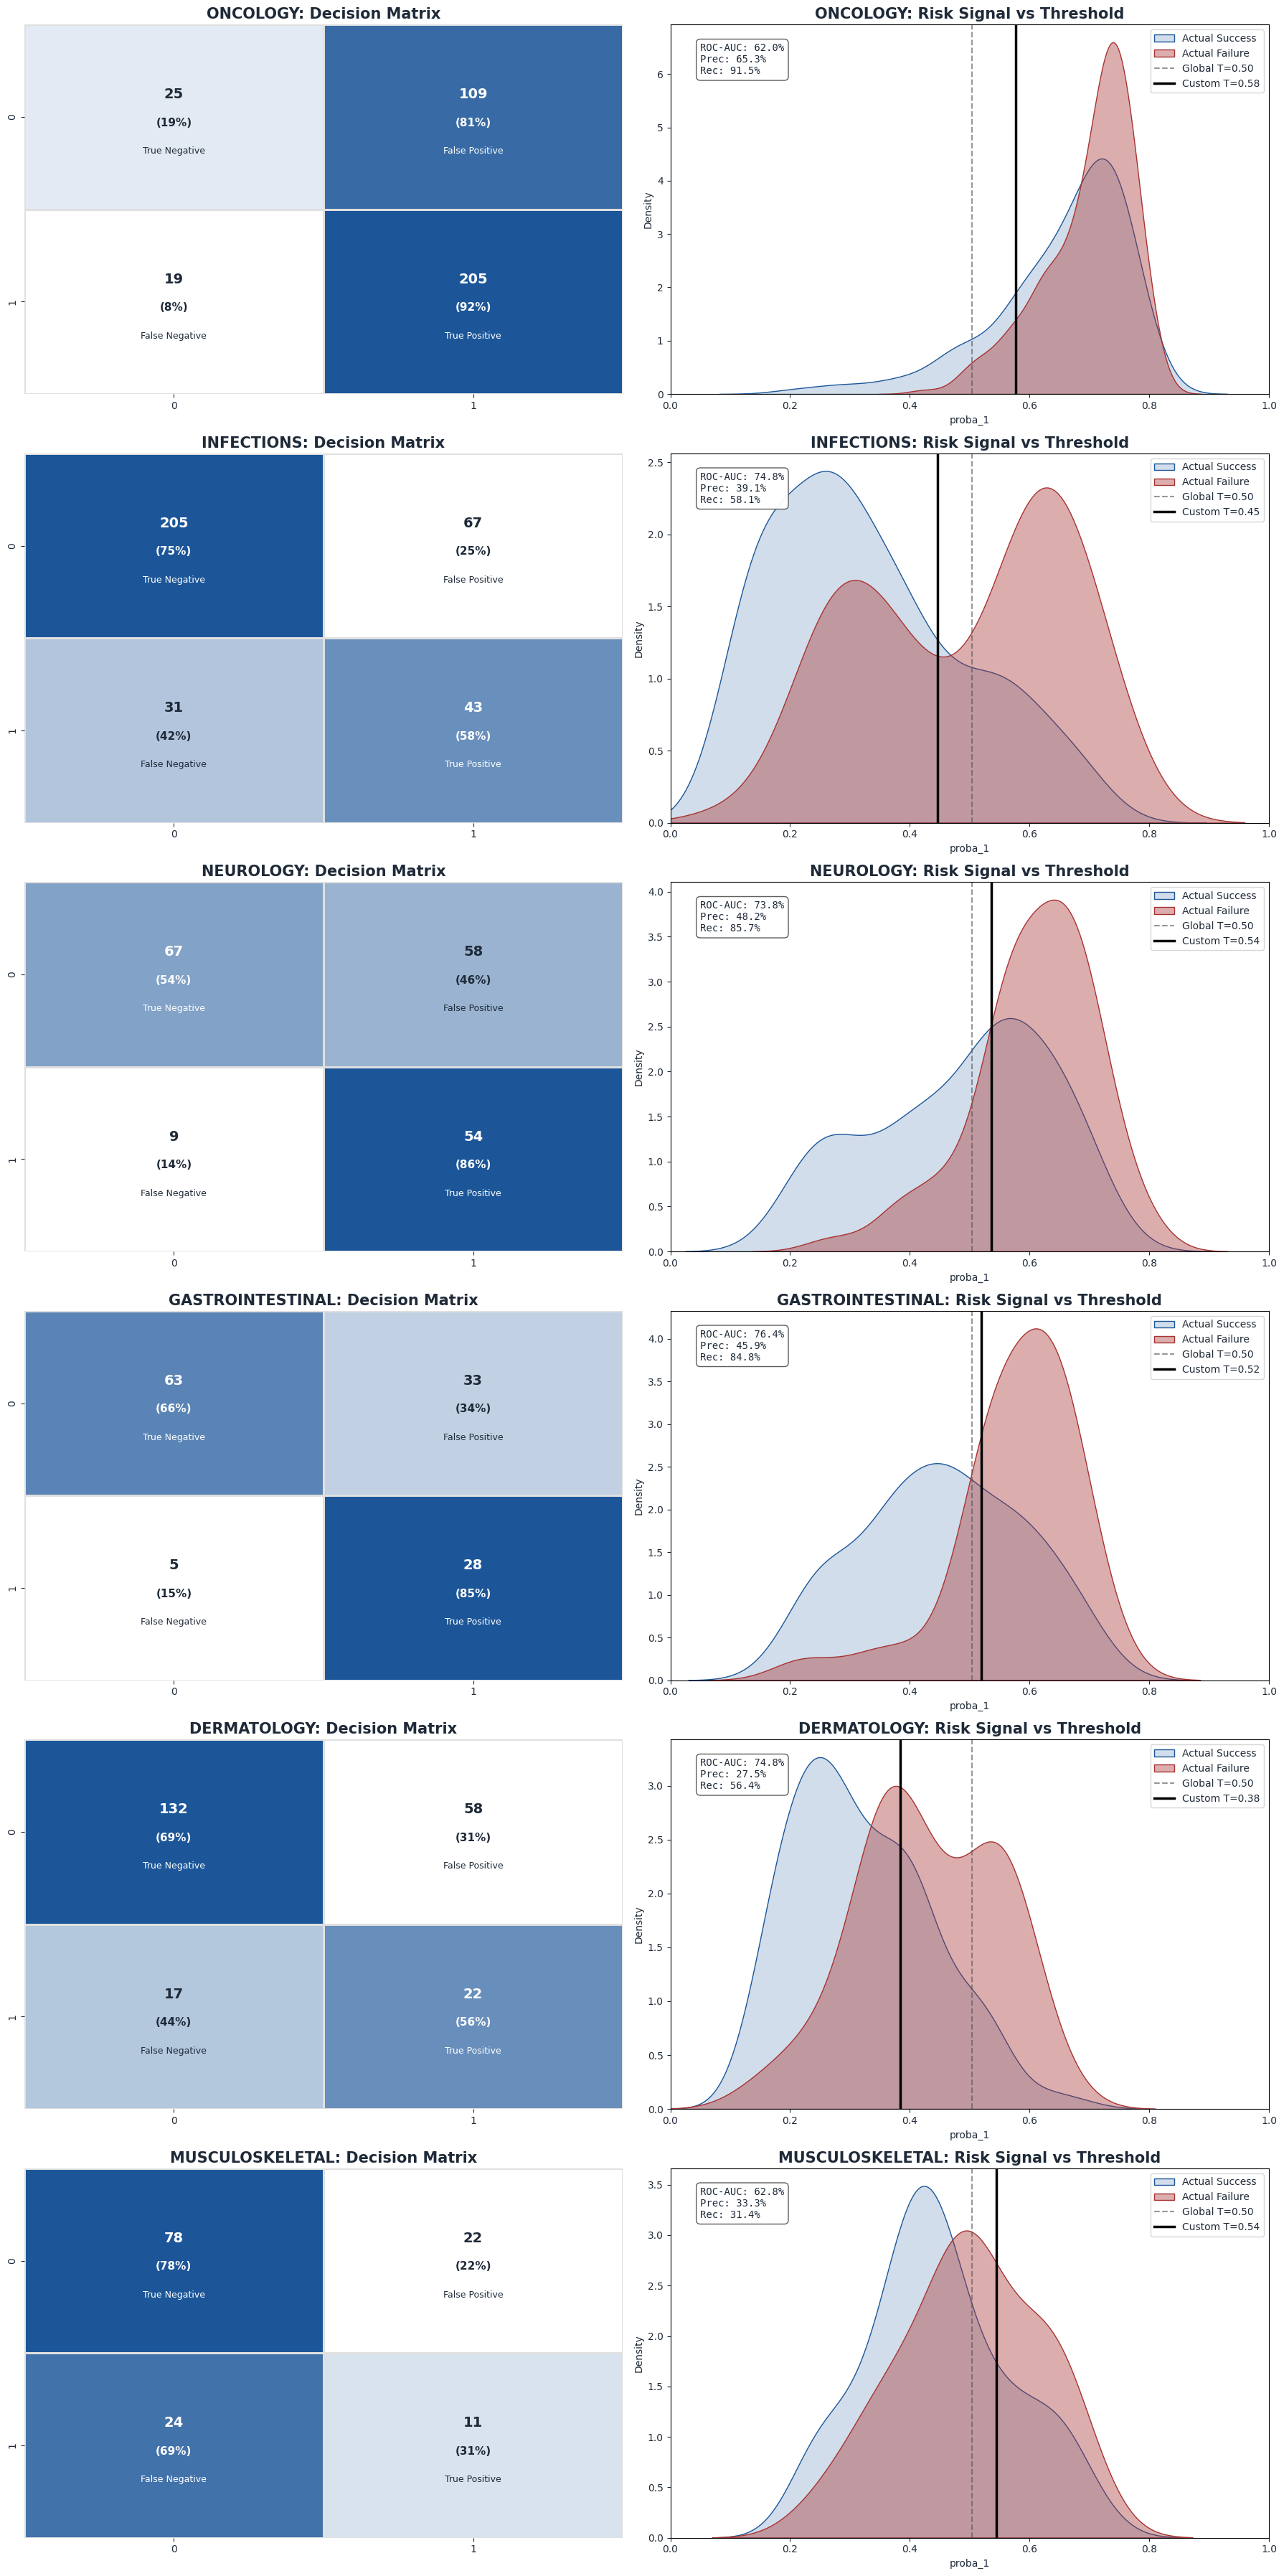

In [21]:
# <REF:TA_FINAL_ANALYSIS_CODE>
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_score, recall_score, roc_auc_score

print('>>> STEP 16: COMPREHENSIVE THERAPEUTIC AREA ANALYSIS ...')

# 1. PROFILE DISTRIBUTIONS (Train vs Test)
train_counts = df_cal['TA'].value_counts()
train_fail_rates = df_cal.groupby('TA')['true'].mean()
test_counts = test_results['therapeutic_area'].value_counts()
test_fail_rates = test_results.groupby('therapeutic_area')['target'].mean()

# 2. CALCULATE PER-TA PERFORMANCE (SYNCED WITH AUDIT)
ta_performance = []
all_tas = sorted(test_results['therapeutic_area'].unique())

for ta in all_tas:
    mask = test_results['therapeutic_area'] == ta
    if mask.sum() == 0: continue

    y_sub_true = test_results.loc[mask, 'target']
    y_sub_prob = test_results.loc[mask, 'proba_1']

    # --- SYNC LOGIC: Probability-Space Matching ---
    ta_thresh = final_thresholds.get(ta, global_thresh)
    y_sub_pred = (y_sub_prob >= ta_thresh).astype(int)

    try:
        auc_val = roc_auc_score(y_sub_true, y_sub_prob) if y_sub_true.nunique() > 1 else np.nan
    except: auc_val = np.nan

    ta_performance.append({
        'TA': ta,
        'Train N': train_counts.get(ta, 0),
        'Train Fail%': train_fail_rates.get(ta, 0.0),
        'Test N': test_counts.get(ta, 0),
        'Test Fail%': test_fail_rates.get(ta, 0.0),
        'AUC': auc_val,
        'Prec': precision_score(y_sub_true, y_sub_pred, zero_division=0),
        'Rec': recall_score(y_sub_true, y_sub_pred, zero_division=0),
        'Thresh': ta_thresh
    })

df_ta_stats = pd.DataFrame(ta_performance).sort_values('Train N', ascending=False)

# --- AGGREGATE STRATEGY REPORT (100% Audit Match) ---
row_thresholds = test_results['therapeutic_area'].map(final_thresholds).fillna(global_thresh)
y_strategy_pred = (test_results['proba_1'] >= row_thresholds).astype(int)

total_row = {
    'TA': 'TOTAL (Strategy)',
    'Train N': len(df_cal), 'Train Fail%': df_cal['true'].mean(),
    'Test N': len(test_results), 'Test Fail%': test_results['target'].mean(),
    'AUC': roc_auc_score(test_results['target'], test_results['proba_1']),
    'Prec': precision_score(test_results['target'], y_strategy_pred),
    'Rec': recall_score(test_results['target'], y_strategy_pred),
    'Thresh': global_thresh
}
df_final_report = pd.concat([pd.DataFrame([total_row]), df_ta_stats], ignore_index=True)

print('\n=== THERAPEUTIC AREA COMPARATIVE STATISTICS (SYNCED) ===')
display_df = df_final_report.copy()
format_map = {'Train Fail%': '{:.1%}', 'Test Fail%': '{:.1%}', 'AUC': '{:.3f}', 'Prec': '{:.1%}', 'Rec': '{:.1%}', 'Thresh': '{:.4f}'}
for col, fmt in format_map.items(): display_df[col] = display_df[col].map(lambda x: fmt.format(x) if pd.notnull(x) else 'N/A')
print(display_df.to_string(index=False))

# 3. RESTORED HIGH-FIDELITY DEEP DIVES
def plot_ta_deep_dive_restored(df_results, target_tas, global_t, thresh_map):
    n_tas = len(target_tas)
    fig, axes = plt.subplots(n_tas, 2, figsize=(18, 6 * n_tas), facecolor='white')
    if n_tas == 1: axes = np.array([axes])
    plt.subplots_adjust(hspace=0.4, wspace=0.2)
    names = [['True Negative', 'False Positive'], ['False Negative', 'True Positive']]

    for i, ta in enumerate(target_tas):
        mask = df_results['therapeutic_area'] == ta
        if mask.sum() == 0: continue
        y_true_ta, y_prob_ta = df_results.loc[mask, 'target'], df_results.loc[mask, 'proba_1']
        ta_t = thresh_map.get(ta, global_t); y_pred_ta = (y_prob_ta >= ta_t).astype(int)

        ax_cm = axes[i, 0]; cm = confusion_matrix(y_true_ta, y_pred_ta)
        cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        sns.heatmap(cm_perc, fmt="", cmap=cmap_conf, ax=ax_cm, cbar=False, linewidths=1, linecolor='#e0e0e0')
        for x in range(2):
            for y in range(2):
                val, pct = cm[x,y], cm_perc[x,y]
                color = "white" if pct > 0.5 else UI_COLORS['text_main']
                ax_cm.text(y+0.5, x+0.4, f"{val}", ha='center', color=color, fontweight='bold', fontsize=14)
                ax_cm.text(y+0.5, x+0.55, f"({pct:.0%})", ha='center', color=color, fontweight='bold', fontsize=11)
                ax_cm.text(y+0.5, x+0.7, f"{names[x][y]}", ha='center', color=color, fontsize=9)
        ax_cm.set_title(f'{ta}: Decision Matrix', fontsize=15, fontweight='bold')

        ax_dens = axes[i, 1]
        sns.kdeplot(y_prob_ta[y_true_ta == 0], fill=True, color=UI_COLORS['succ_deep'], label='Actual Success', ax=ax_dens, alpha=0.2)
        sns.kdeplot(y_prob_ta[y_true_ta == 1], fill=True, color=UI_COLORS['fail_deep'], label='Actual Failure', ax=ax_dens, alpha=0.4)
        ax_dens.axvline(global_t, **ref_line_style, label=f'Global T={global_t:.2f}')
        ax_dens.axvline(ta_t, color='black', linestyle='-', linewidth=2.5, label=f'Custom T={ta_t:.2f}')
        ax_dens.set_title(f'{ta}: Risk Signal vs Threshold', fontsize=15, fontweight='bold')
        ax_dens.set_xlim(0, 1); ax_dens.legend(loc='upper right')

        stats = f"ROC-AUC: {roc_auc_score(y_true_ta, y_prob_ta):.1%}\nPrec: {precision_score(y_true_ta, y_pred_ta, zero_division=0):.1%}\nRec: {recall_score(y_true_ta, y_pred_ta, zero_division=0):.1%}"
        ax_dens.text(0.05, 0.95, stats, transform=ax_dens.transAxes, verticalalignment='top', bbox=box_style, fontsize=10, fontfamily='monospace')
    plt.tight_layout(); plt.show()

print('\n>>> RENDERING TOP 6 THERAPEUTIC AREA DEEP DIVES (RESTORED FIDELITY) ...')
top_tas = df_ta_stats.head(6)['TA'].tolist()
plot_ta_deep_dive_restored(test_results, top_tas, global_thresh, final_thresholds)
# <REF:/TA_FINAL_ANALYSIS_CODE>


#### <REF:TA_RESULTS>
> #### **17. Strategic Insights: Performance Stability & Risk Evolution (v33.0)**

**1. Learning Curve & Data Maturity**
The rolling temporal validation confirms a strong positive correlation between training volume and ranking power. The model reached **maturity at 10,000 trials** (Fold 3, AUC: 0.7049) and achieved **peak performance in the most recent window** (Fold 6, AUC: 0.7359) with over 20,000 records. 

**2. Environmental Drift & Failure Volatility**
A profound shift in the clinical risk landscape is evident. Failure rates surged from **18.6%** in the training era to **31.1%** in the 2021-2022 test set. Despite this 12.5% jump in baseline risk, the model maintained high ranking stability, with PR-AUC climbing to **0.5596**. This resilience demonstrates that the engine is identifying fundamental drivers of failure that persist in a more volatile modern era.

**3. Generalization through One-Shot Categorization**
The model exhibits exceptional generalization, with **ROC-AUC increasing from 0.7268 (Train) to 0.7454 (Test)**. This performance is driven by the **'One-Shot' Categorization Strategy** (Runs 1-4), which translates raw clinical text into structured, logic-locked features (e.g., Innovation Tier, Comparator Benchmark). By relying on these high-signal enums rather than raw text embeddings, the system effectively bypasses the leakage traps inherent in post-hoc linguistic patterns.

**4. Decision Policy & Strategic Lift**
Under the **Hybrid Strategy** (TA-specific calibration), the engine delivers a high-fidelity decision signal:
*   **Precision Lift:** Achieves a **1.48x lift** over the baseline failure rate, indicating the AI is nearly 50% more efficient at identifying failures than a random audit.
*   **Recall Efficiency:** Captures **75.1% of all failures** while maintaining a 46.1% precision. 
*   **Stability:** The F-Beta score improved from 0.4278 to **0.5712** in the test set, indicating that the decision policy becomes more reliable as the clinical environment becomes more challenging.

**Conclusion:**
The system operates as a **mature, calibrated risk engine**. It successfully navigates significant environmental drift by leveraging a specialized LLM categorization protocol that prioritizes clinical logic over raw text. With its 10k+ trial maturity, it delivers a **Clinical Success Score** that is both statistically robust and strategically honest.

***
